Author: Dinghao Luo  
Date  : 26 March 2026

This notebook implements a simple, schematic model of the LC-DA-CA1 PyrUp dataset from Luo et al. (2026). The goal is not to build a detailed biophysical model, but to support a mechanistic interpretation of the main results in the paper.

In this version, dopamine modulation is smooth and firing-rate dependent rather than thresholded. The direct task-related drives set an instantaneous pre-DA firing-rate-like signal, dopamine scales that signal most strongly once a cell is already fairly active, and a separate cell-intrinsic recovery constant slows the return to baseline.

The model has three drive terms:
- $R(t)$: a run-related excitatory drive
- $W(t)$: a reward-associated suppressive drive
- $D(t)$: a dopamine modulation signal

The dopamine signal is built from two parts:
- a transient pre-run DA dip before trial start
- a delayed positive DA component generated from LC-triggered release

For each CA1 cell $i$, the baseline input is
$$x_i(t) = b_i + w_i^R R(t) + w_i^W W(t)$$

This is converted into a non-negative firing-rate-like quantity using a softplus nonlinearity:
$$r_i^0(t) = \phi\left(x_i(t)\right)$$

DA modulation is then gated smoothly by the current pre-DA firing rate:
$$m_i(t) = \sigma\left(\frac{r_i^0(t) - r_{1/2}}{k_r}\right)$$
where $r_{1/2}$ sets the turning point of the DA effect and $k_r$ controls how sharply that effect ramps up. With this form, DA effects stay small below the chosen turning point and grow smoothly above it, without a hard threshold.

The DA-scaled drive is
$$r_i^{\mathrm{drive}}(t) = r_i^0(t)\left[1 + g_i D(t)m_i(t)\right]$$

Finally, each cell has its own intrinsic recovery time constant. In the implementation below, rising drive is followed quickly, but when the drive starts to fall the cell relaxes back towards baseline with a cell-specific time constant $\tau_i^{\mathrm{intr}}$. This is a simple way to capture the idea that different cells can recover to baseline at different speeds even after the direct run and reward drives have already decayed.

Here:
- $b_i$ is the baseline excitability of cell $i$
- $w_i^R$ and $w_i^W$ are that cell's sensitivities to run and reward-related inputs
- $r_{1/2}$ is the DA-gating turning point in firing-rate units
- $k_r$ sets the steepness of the smooth DA recruitment curve
- $g_i$ sets the strength of DA gain modulation
- $\tau_i^{\mathrm{intr}}$ is the cell-specific intrinsic recovery time constant


In [ ]:
# imports
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass

In [ ]:
@dataclass
class PARAMS:
    # simulation grid
    dt: float     = 0.01
    t_pre: float  = 1.00
    t_post: float = 6.00

    # population size
    n_cells: int = 1000

    # population priors
    baseline_mean: float = 1.80
    baseline_sd: float   = 0.35

    wR_mean: float = 1.00
    wR_sd: float   = 0.60
    wW_mean: float = 0.60
    wW_sd: float   = 0.90

    # DA-targeting and smooth rate dependence
    frac_da_targ: float = 0.30
    da_half_rate: float = 2.50
    da_rate_slope: float = 0.35
    da_gain: float      = 1.20

    # cell-intrinsic recovery constants
    intrinsic_tau_mean: float = 0.75
    intrinsic_tau_sd: float   = 0.15
    intrinsic_tau_min: float  = 0.35
    intrinsic_tau_max: float  = 1.40

    # static nonlinearity / output limits
    softplus_beta: float = 2.00
    max_rate: float      = 20.00

    # drive timings
    drive_end: float         = 5.00
    direct_drive_end: float  = 3.00
    run_peak_t: float        = 1.00
    reward_trough_t: float   = 1.00
    da_dip_t: float          = -0.25
    da_dip_tau: float        = 0.20

    # drive amplitudes
    run_amp: float    = 1.10
    reward_amp: float = 1.20
    da_dip_amp: float = -0.50

    # LC drive shape
    lc_baseline: float = 1.00
    lc_amp: float      = 2.00
    lc_mu: float       = 0.00
    lc_sigma: float    = 0.25

    # LC -> DA conversion
    lc_thresh_delta: float = 0.80
    lc_to_da_gain: float   = 1.00
    da_tau_decay: float    = 0.90

    # population analysis
    pre_window: tuple  = (-1.00, -0.50)
    post_window: tuple = (0.50, 1.50)
    up_thresh: float   = 3 / 2
    down_thresh: float = 2 / 3

    # numerical safeguard
    eps: float = 1e-6


In [ ]:
# analysis helpers
def window_mask(t, window):
    return (t >= window[0]) & (t < window[1])

def response_strength(rates, t, p):
    '''returns the response strength for each cell'''
    pre_window  = p.pre_window
    post_window = p.post_window

    pre_mask  = window_mask(t, pre_window)
    post_mask = window_mask(t, post_window)

    pre_mean  = np.mean(rates[:, pre_mask], axis=1)
    post_mean = np.mean(rates[:, post_mask], axis=1)

    return post_mean / (pre_mean + p.eps)

def classify_cells(response_strength, p):
    '''classifies cells into up, down, or other'''
    is_up    = response_strength >= p.up_thresh
    is_down  = response_strength <= p.down_thresh
    is_other = ~(is_up | is_down)

    return {
        'is_up': is_up,
        'is_down': is_down,
        'is_other': is_other
    }

# drive construction
def make_drives(t, p, return_components=False):
    '''returns R, W, D or, if requested, a dict of all drive components'''

    def half_cosine(tt, t0, t1, y0, y1):
        '''returns a half-cosine drive between t0 and t1 with amplitude y1-y0'''
        s = np.clip((tt - t0) / (t1 - t0), 0.0, 1.0)
        return y0 + (y1 - y0) * 0.5 * (1.0 - np.cos(np.pi * s))

    def exp_kernel(dt, tau, t_max):
        '''
        causal exponential kernel with unit area
        so lc_to_da_gain controls the overall amplitude cleanly
        '''
        tk = np.arange(0.0, t_max + dt, dt)
        k = np.exp(-tk / tau)
        k /= (np.sum(k) * dt + p.eps)
        return tk, k

    R = np.zeros_like(t, dtype=float)
    W = np.zeros_like(t, dtype=float)
    D_dip = np.zeros_like(t, dtype=float)

    # run drive:
    # 0 before run onset, rise from 0 to run_amp, then decay back by second direct_drive_end
    rise_mask = (t >= 0.0) & (t <= p.run_peak_t)
    decay_mask = (t > p.run_peak_t) & (t <= p.direct_drive_end)

    R[rise_mask] = half_cosine(t[rise_mask], 0.0, p.run_peak_t, 0.0, p.run_amp)
    R[decay_mask] = half_cosine(t[decay_mask], p.run_peak_t, p.direct_drive_end, p.run_amp, 0.0)

    # reward drive:
    # 0 before run onset, ramp down to a negative trough then recover by second direct_drive_end
    down_mask = (t >= 0.0) & (t <= p.reward_trough_t)
    recover_mask = (t > p.reward_trough_t) & (t <= p.direct_drive_end)

    W[down_mask] = half_cosine(t[down_mask], 0.0, p.reward_trough_t, 0.0, -p.reward_amp)
    W[recover_mask] = half_cosine(t[recover_mask], p.reward_trough_t, p.direct_drive_end, -p.reward_amp, 0.0)

    # dopamine drive:
    # dip down before run onset, then recover smoothly back to 0
    dip_down_mask = (t >= -p.t_pre) & (t <= p.da_dip_t)
    dip_recover_mask = t > p.da_dip_t

    D_dip[dip_down_mask] = half_cosine(
        t[dip_down_mask], -p.t_pre, p.da_dip_t, 0.0, p.da_dip_amp
    )
    D_dip[dip_recover_mask] = p.da_dip_amp * np.exp(
        -(t[dip_recover_mask] - p.da_dip_t) / p.da_dip_tau
    )

    # LC gaussian centred at run onset
    L = p.lc_baseline + p.lc_amp * np.exp(-0.5 * ((t - p.lc_mu) / p.lc_sigma) ** 2)

    # only the part significantly above baseline contributes to DA release
    lc_excess = np.maximum(L - (p.lc_baseline + p.lc_thresh_delta), 0.0)

    # convolve LC excess with a causal exponential kernel
    # this makes DA release follow LC on the rise, but decay with its own time constant
    tk, k = exp_kernel(p.dt, p.da_tau_decay, p.t_pre + p.t_post)
    D_release = p.lc_to_da_gain * np.convolve(lc_excess, k, mode='full')[:len(t)] * p.dt

    # total DA trace = preexisting dip + LC-induced release
    D = D_dip + D_release

    if return_components:
        return {
            'R': R,
            'W': W,
            'D': D,
            'L': L,
            'D_dip': D_dip,
            'D_release': D_release,
            'lc_excess': lc_excess,
            'kernel_t': tk,
            'kernel': k
        }

    return R, W, D


In [ ]:
# simulation code
def apply_intrinsic_decay_trace(r_drive, tau_intr, dt, max_rate):
    '''Applies a cell-specific slow recovery only on the falling phase.'''
    r = np.zeros_like(r_drive)
    r[0] = r_drive[0]
    alpha = dt / max(tau_intr, 1e-6)

    for k in range(1, len(r_drive)):
        if r_drive[k] >= r[k - 1]:
            r[k] = r_drive[k]
        else:
            r[k] = r[k - 1] + alpha * (r_drive[k] - r[k - 1])

    return np.clip(r, 0.0, max_rate)


def apply_intrinsic_decay_matrix(r_drive, tau_intr, dt, max_rate):
    '''Vectorised version of the same recovery rule for population simulations.'''
    r = np.zeros_like(r_drive)
    r[:, 0] = r_drive[:, 0]
    alpha = dt / np.maximum(tau_intr, 1e-6)

    for k in range(1, r_drive.shape[1]):
        target = r_drive[:, k]
        prev = r[:, k - 1]
        rising = target >= prev

        r[rising, k] = target[rising]
        r[~rising, k] = prev[~rising] + alpha[~rising] * (target[~rising] - prev[~rising])

    return np.clip(r, 0.0, max_rate)


def simulate_one_cell(t, p, cell, R, W, D):
    '''
    simulates one cell's FR profile given run, reward, and DA drives

    parameters:
    - t: time vector (s)
    - p: PARAMS object
    - cell: dict with keys 'b', 'wR', 'wW', 'tau_intr', 'da_targ'
    - R: run drive (all these drives have the same length as t)
    - W: reward drive
    - D: DA drive

    returns:
    - out: dict containing intermediate variables and final firing rate profile (length = len(t))
    '''
    dt = p.dt
    if not np.allclose(np.diff(t), dt):
        raise ValueError('Time vector t must have uniform steps of size p.dt')

    # build pre-DA linear drive sum
    x = cell['b'] + cell['wR'] * R + cell['wW'] * W

    # rectify pre-DA drive into non-negative firing rate
    xb = p.softplus_beta * x
    r0 = (np.log1p(np.exp(-np.abs(xb))) + np.maximum(xb, 0.0)) / p.softplus_beta

    # smooth DA recruitment: small below the turning point, stronger above it
    slope = max(p.da_rate_slope, p.eps)
    m = 1.0 / (1.0 + np.exp(-(r0 - p.da_half_rate) / slope))

    # multiplicative DA gain, restricted to the DA-targeted subpopulation
    gain = 1.0 + float(cell['da_targ']) * p.da_gain * m * D
    r_drive = np.clip(r0 * gain, 0.0, p.max_rate)

    # cell-intrinsic recovery: rising phases track the drive quickly,
    # but falling phases relax back more slowly with tau_intr
    r = apply_intrinsic_decay_trace(r_drive, cell['tau_intr'], p.dt, p.max_rate)

    return {
        'x': x,
        'r0': r0,
        'm': m,
        'gain': gain,
        'r_drive': r_drive,
        'r': r,
        'tau_intr': cell['tau_intr']
    }


def make_population(p, rng):
    '''makes a population of cells with parameters drawn from distributions specified in PARAMS'''
    b = rng.normal(p.baseline_mean, p.baseline_sd, p.n_cells)

    wR = rng.normal(p.wR_mean, p.wR_sd, p.n_cells)
    wW = rng.normal(p.wW_mean, p.wW_sd, p.n_cells)

    tau_intr = np.clip(
        rng.normal(p.intrinsic_tau_mean, p.intrinsic_tau_sd, p.n_cells),
        p.intrinsic_tau_min,
        p.intrinsic_tau_max
    )

    da_u = rng.random(p.n_cells)
    da_targ = da_u < p.frac_da_targ

    return {
        'b': b,
        'wR': wR,
        'wW': wW,
        'tau_intr': tau_intr,
        'da_u': da_u,
        'da_targ': da_targ
    }


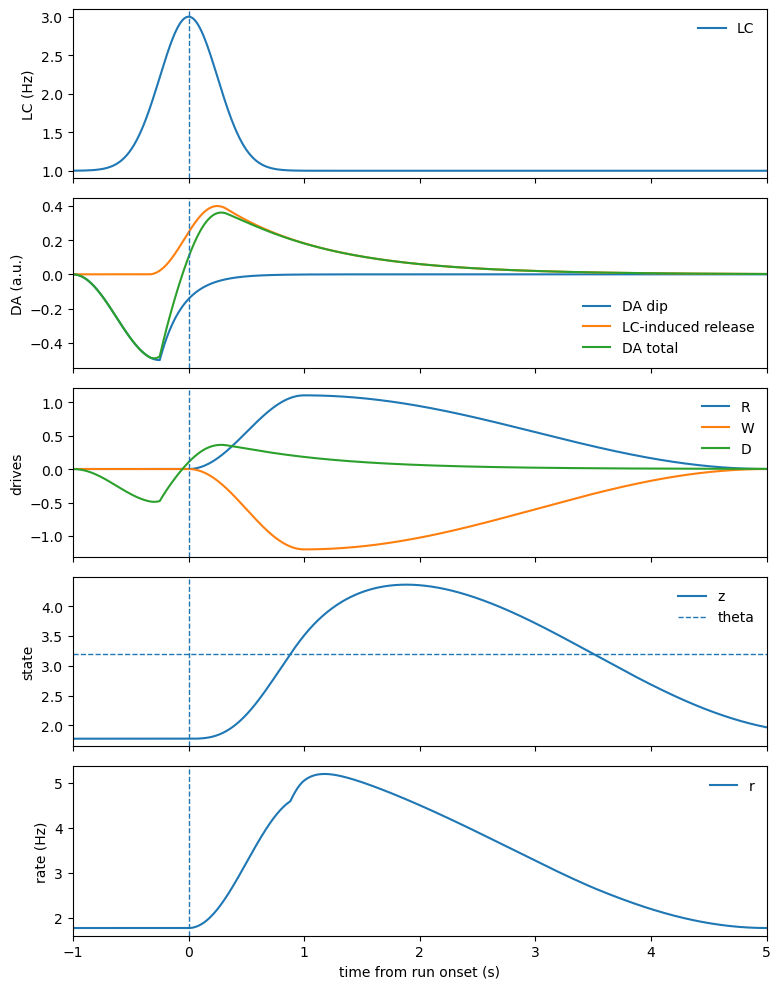

cell index: 648
{'b': 1.762455807766103, 'wR': 2.337759087893642, 'wW': -0.30155003336769104, 'theta': 3.1966935716349516, 'da_targ': True}


In [ ]:
# visual inspection first
rng = np.random.default_rng(0)
p = PARAMS()

t = np.arange(-p.t_pre, p.t_post, p.dt)

comp = make_drives(t, p, return_components=True)
R = comp['R']
W = comp['W']
D = comp['D']
L = comp['L']
D_dip = comp['D_dip']
D_release = comp['D_release']

# make one population
pop = make_population(p, rng)

# pick one DA-targeted cell that is run-sensitive and has a moderately long recovery tau
cand = np.where(pop['da_targ'])[0]
score = pop['wR'][cand] - 0.5 * np.maximum(pop['wW'][cand], 0.0) + 0.25 * pop['tau_intr'][cand]
i = cand[np.argmax(score)]

cell = {
    'b': pop['b'][i],
    'wR': pop['wR'][i],
    'wW': pop['wW'][i],
    'tau_intr': pop['tau_intr'][i],
    'da_targ': pop['da_targ'][i]
}

out = simulate_one_cell(t, p, cell, R, W, D)

fig, axes = plt.subplots(5, 1, figsize=(8, 10), sharex=True)

# LC peak
axes[0].plot(t, L, label='LC')
axes[0].axvline(0, linestyle='--', linewidth=1)
axes[0].legend(frameon=False)
axes[0].set_ylabel('LC (Hz)')

# DA parts
axes[1].plot(t, D_dip, label='DA dip')
axes[1].plot(t, D_release, label='LC-induced release')
axes[1].plot(t, D, label='DA total')
axes[1].axvline(0, linestyle='--', linewidth=1)
axes[1].legend(frameon=False)
axes[1].set_ylabel('DA (a.u.)')

# all drives
axes[2].plot(t, R, label='R')
axes[2].plot(t, W, label='W')
axes[2].plot(t, D, label='D')
axes[2].axvline(0, linestyle='--', linewidth=1)
axes[2].legend(frameon=False)
axes[2].set_ylabel('drives')

# smooth rate-dependent DA recruitment
axes[3].plot(t, out['r0'], label='pre-DA rate')
axes[3].axhline(p.da_half_rate, linestyle='--', linewidth=1, label='DA midpoint')
axes[3].axvline(0, linestyle='--', linewidth=1)
axes[3].legend(frameon=False)
axes[3].set_ylabel('rate (Hz)')
axes[3].set_title(f'sigmoid gate midpoint = {p.da_half_rate:.2f} Hz, slope = {p.da_rate_slope:.2f} Hz')

# drive-level rate vs final rate after cell-intrinsic recovery
axes[4].plot(t, out['r_drive'], linestyle='--', linewidth=1.5, label='drive-level rate')
axes[4].plot(t, out['r'], linewidth=2, label='final rate')
axes[4].axvline(0, linestyle='--', linewidth=1)
axes[4].legend(frameon=False)
axes[4].set_ylabel('rate (Hz)')
axes[4].set_xlabel('time from run onset (s)')

for ax in axes:
    ax.set_xlim([-p.t_pre, p.drive_end])

plt.tight_layout()
plt.show()

print(f'cell index: {i}')
print(cell)


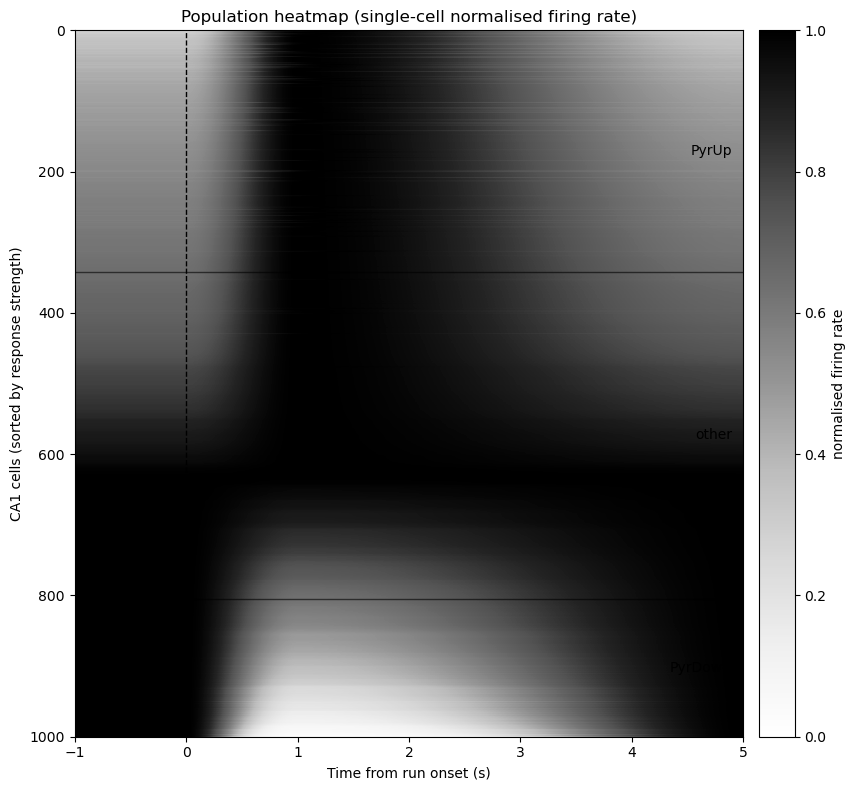

PyrUp: 342 / 1000 (34.2%)
other: 463 / 1000 (46.3%)
PyrDown: 195 / 1000 (19.5%)
DA-targeted: 300 / 1000 (30.0%)


In [ ]:
# population-level simulation and heatmap
rng = np.random.default_rng(0)
p = PARAMS()

t = np.arange(-p.t_pre, p.t_post, p.dt)
R, W, D = make_drives(t, p)
zero_da = np.zeros_like(D)

pop = make_population(p, rng)

def make_cell_from_population(pop, i):
    return {
        'b': pop['b'][i],
        'wR': pop['wR'][i],
        'wW': pop['wW'][i],
        'theta': pop['theta'][i],
        'da_targ': pop['da_targ'][i]
    }

pop_out = []
pop_out_no_da = []
for i in range(p.n_cells):
    cell = make_cell_from_population(pop, i)
    pop_out.append(simulate_one_cell(t, p, cell, R, W, D))
    pop_out_no_da.append(simulate_one_cell(t, p, cell, R, W, zero_da))

rates = np.vstack([out['r'] for out in pop_out])
rates_no_da = np.vstack([out['r'] for out in pop_out_no_da])

resp = response_strength(rates, t, p)
classes = classify_cells(resp, p)

cell_peak = np.max(rates, axis=1, keepdims=True)
rates_norm = rates / np.maximum(cell_peak, p.eps)

order = np.argsort(resp)[::-1]
rates_heatmap = rates_norm[order]

n_up = int(np.sum(resp[order] >= p.up_thresh))
n_not_down = int(np.sum(resp[order] > p.down_thresh))

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(
    rates_heatmap,
    aspect='auto',
    cmap='Greys',
    vmin=0.0,
    vmax=1.0,
    extent=[t[0], t[-1], p.n_cells, 0]
)

ax.axvline(0, linestyle='--', color='k', linewidth=1)
ax.axhline(n_up, color='k', linewidth=1, alpha=0.6)
ax.axhline(n_not_down, color='k', linewidth=1, alpha=0.6)

label_x = p.drive_end - 0.1
ax.text(label_x, n_up / 2, 'PyrUp', ha='right', va='center')
ax.text(label_x, (n_up + n_not_down) / 2, 'other', ha='right', va='center')
ax.text(label_x, (n_not_down + p.n_cells) / 2, 'PyrDown', ha='right', va='center')

ax.set_xlim([-p.t_pre, p.drive_end])
ax.set_xlabel('Time from run onset (s)')
ax.set_ylabel('CA1 cells (sorted by response strength)')
ax.set_title('Population heatmap (single-cell normalised firing rate)')

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('normalised firing rate')

plt.tight_layout()
plt.show()

n_up_total = int(classes['is_up'].sum())
n_other_total = int(classes['is_other'].sum())
n_down_total = int(classes['is_down'].sum())

print(f'PyrUp: {n_up_total} / {p.n_cells} ({100 * n_up_total / p.n_cells:.1f}%)')
print(f'other: {n_other_total} / {p.n_cells} ({100 * n_other_total / p.n_cells:.1f}%)')
print(f'PyrDown: {n_down_total} / {p.n_cells} ({100 * n_down_total / p.n_cells:.1f}%)')
print(f'DA-targeted: {int(pop["da_targ"].sum())} / {p.n_cells} ({100 * pop["da_targ"].mean():.1f}%)')


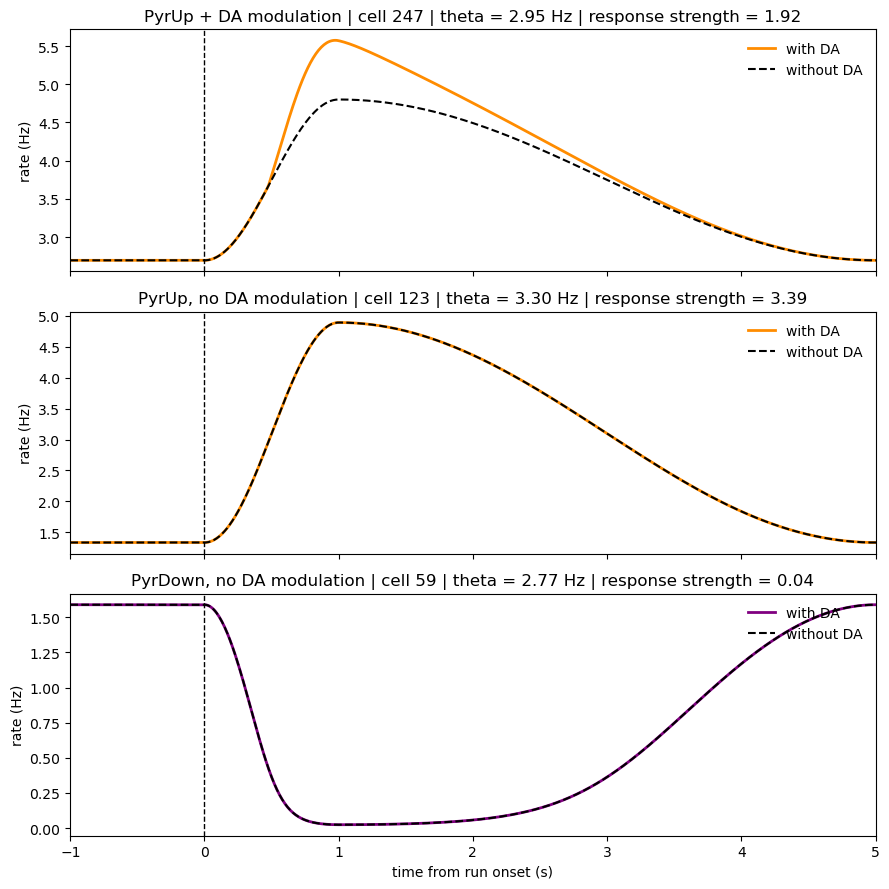

PyrUp + DA modulation: cell 247, theta=2.95, da_targ=True, response_strength=1.92, post_run_DA_effect=0.59, pre_run_DA_effect=0.00
PyrUp, no DA modulation: cell 123, theta=3.30, da_targ=False, response_strength=3.39, post_run_DA_effect=0.00, pre_run_DA_effect=0.00
PyrDown, no DA modulation: cell 59, theta=2.77, da_targ=False, response_strength=0.04, post_run_DA_effect=0.00, pre_run_DA_effect=0.00


In [ ]:
# representative single-cell examples
post_mask = window_mask(t, p.post_window)
pre_run_mask = t < 0

da_effect = np.mean(rates[:, post_mask] - rates_no_da[:, post_mask], axis=1)
pre_da_effect = np.mean(rates[:, pre_run_mask] - rates_no_da[:, pre_run_mask], axis=1)

up_da_candidates = np.where(classes['is_up'] & pop['da_targ'] & (pre_da_effect >= -1e-6))[0]
if up_da_candidates.size == 0:
    up_da_candidates = np.where(classes['is_up'] & pop['da_targ'])[0]

up_no_da_candidates = np.where(classes['is_up'] & ~pop['da_targ'])[0]
down_no_da_candidates = np.where(classes['is_down'] & ~pop['da_targ'])[0]

if up_da_candidates.size == 0:
    raise RuntimeError('No DA-targeted PyrUp cells were found in this population.')
if up_no_da_candidates.size == 0:
    raise RuntimeError('No non-DA-targeted PyrUp cells were found in this population.')
if down_no_da_candidates.size == 0:
    raise RuntimeError('No non-DA-targeted PyrDown cells were found in this population.')

da_score = da_effect[up_da_candidates] - 0.75 * np.abs(pop['theta'][up_da_candidates] - p.theta_mean)
idx_up_da = up_da_candidates[np.argmax(da_score)]
idx_up_no_da = up_no_da_candidates[np.argmax(resp[up_no_da_candidates])]
idx_down_no_da = down_no_da_candidates[np.argmin(resp[down_no_da_candidates])]

if da_effect[idx_up_da] <= 0.05:
    raise RuntimeError('The most DA-sensitive PyrUp cell in this population still shows only weak DA modulation.')

example_cells = [
    ('PyrUp + DA modulation', idx_up_da, 'darkorange'),
    ('PyrUp, no DA modulation', idx_up_no_da, 'darkorange'),
    ('PyrDown, no DA modulation', idx_down_no_da, 'purple')
]

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for ax, (title, idx, color) in zip(axes, example_cells):
    ax.plot(t, rates[idx], color=color, linewidth=2, label='with DA')
    ax.plot(t, rates_no_da[idx], color='k', linestyle='--', linewidth=1.5, label='without DA')
    ax.axvline(0, linestyle='--', color='k', linewidth=1)
    ax.set_xlim([-p.t_pre, p.drive_end])
    ax.set_ylabel('rate (Hz)')
    ax.set_title(
        f'{title} | cell {idx} | theta = {pop["theta"][idx]:.2f} Hz | '
        f'response strength = {resp[idx]:.2f}'
    )
    ax.legend(frameon=False, loc='upper right')

axes[-1].set_xlabel('time from run onset (s)')

plt.tight_layout()
plt.show()

for title, idx, _ in example_cells:
    print(
        f'{title}: cell {idx}, '
        f'theta={pop["theta"][idx]:.2f}, '
        f'da_targ={bool(pop["da_targ"][idx])}, '
        f'response_strength={resp[idx]:.2f}, '
        f'post_run_DA_effect={da_effect[idx]:.2f}, '
        f'pre_run_DA_effect={pre_da_effect[idx]:.2f}'
    )


In [ ]:
# shared helper functions for the intervention and sensitivity tests
class_colors = {
    'is_up': 'darkorange',
    'is_other': 'grey',
    'is_down': 'purple'
}

# keep the same relative ordering of per-cell parameters while allowing
# population means / spreads to vary across interventions
pop_b_z = (pop['b'] - p.baseline_mean) / p.baseline_sd
pop_wR_z = (pop['wR'] - p.wR_mean) / p.wR_sd
pop_wW_z = (pop['wW'] - p.wW_mean) / p.wW_sd
pop_theta_z = (pop['theta'] - p.theta_mean) / p.theta_sd
pop_da_u = pop['da_u']

def safe_mean_trace(rate_matrix, mask):
    if np.sum(mask) == 0:
        return np.full(rate_matrix.shape[1], np.nan)
    return np.mean(rate_matrix[mask], axis=0)

def simulate_fixed_population(p_variant, pop, noise_sd=0.0, noise_seed=1234):
    t_variant = np.arange(-p_variant.t_pre, p_variant.t_post, p_variant.dt)
    R_variant, W_variant, D_variant = make_drives(t_variant, p_variant)

    b_variant = p_variant.baseline_mean + pop_b_z * p_variant.baseline_sd
    wR_variant = p_variant.wR_mean + pop_wR_z * p_variant.wR_sd
    wW_variant = p_variant.wW_mean + pop_wW_z * p_variant.wW_sd
    theta_variant = p_variant.theta_mean + pop_theta_z * p_variant.theta_sd
    da_targ_variant = pop_da_u < p_variant.frac_da_targ

    x = (
        b_variant[:, None]
        + wR_variant[:, None] * R_variant[None, :]
        + wW_variant[:, None] * W_variant[None, :]
    )
    xb = p_variant.softplus_beta * x
    r0 = (np.log1p(np.exp(-np.abs(xb))) + np.maximum(xb, 0.0)) / p_variant.softplus_beta

    if noise_sd > 0:
        rng_noise = np.random.default_rng(noise_seed)
        r0 = np.clip(r0 + rng_noise.normal(0.0, noise_sd, size=r0.shape), 0.0, None)

    z = np.zeros_like(r0)
    z[:, 0] = r0[:, 0]
    alpha = p_variant.dt / p_variant.tau_a
    for k in range(1, len(t_variant)):
        z[:, k] = z[:, k - 1] + alpha * (-z[:, k - 1] + r0[:, k - 1])

    gate0 = 1.0 / (1.0 + np.exp(-(z - theta_variant[:, None]) / p_variant.kappa))
    m = np.clip(2.0 * gate0 - 1.0, 0.0, 1.0)

    gain = 1.0 + da_targ_variant[:, None].astype(float) * p_variant.da_gain * m * D_variant[None, :]
    rates_variant = np.clip(r0 * gain, 0.0, p_variant.max_rate)

    pre_mask_variant = window_mask(t_variant, p_variant.pre_window)
    post_mask_variant = window_mask(t_variant, p_variant.post_window)
    resp_variant = np.mean(rates_variant[:, post_mask_variant], axis=1) / (
        np.mean(rates_variant[:, pre_mask_variant], axis=1) + p_variant.eps
    )
    classes_variant = classify_cells(resp_variant, p_variant)

    return {
        'p': p_variant,
        't': t_variant,
        'R': R_variant,
        'W': W_variant,
        'D': D_variant,
        'b': b_variant,
        'wR': wR_variant,
        'wW': wW_variant,
        'theta': theta_variant,
        'da_targ': da_targ_variant,
        'r0': r0,
        'rates': rates_variant,
        'resp': resp_variant,
        'classes': classes_variant,
        'pre_mask': pre_mask_variant,
        'post_mask': post_mask_variant,
        'mean_traces': {
            'is_up': safe_mean_trace(rates_variant, classes_variant['is_up']),
            'is_other': safe_mean_trace(rates_variant, classes_variant['is_other']),
            'is_down': safe_mean_trace(rates_variant, classes_variant['is_down'])
        }
    }

def fixed_population_metrics(p_variant, pop, lc_fold=5.0, noise_sd=0.0, noise_seed=1234):
    base_out = simulate_fixed_population(p_variant, pop, noise_sd=noise_sd, noise_seed=noise_seed)

    p_high_lc = PARAMS()
    p_high_lc.__dict__.update(p_variant.__dict__)
    p_high_lc.lc_amp = p_variant.lc_amp * lc_fold
    high_lc_out = simulate_fixed_population(p_high_lc, pop, noise_sd=noise_sd, noise_seed=noise_seed)

    p_block = PARAMS()
    p_block.__dict__.update(p_variant.__dict__)
    p_block.lc_to_da_gain = 0.0
    block_out = simulate_fixed_population(p_block, pop, noise_sd=noise_sd, noise_seed=noise_seed)

    da_targ_mask = base_out['da_targ']
    not_da_targ_mask = ~base_out['da_targ']

    return {
        'base_up_pct': 100 * np.mean(base_out['classes']['is_up']),
        'base_down_pct': 100 * np.mean(base_out['classes']['is_down']),
        'high_lc_up_shift': 100 * (
            np.mean(high_lc_out['classes']['is_up']) - np.mean(base_out['classes']['is_up'])
        ),
        'high_lc_down_shift': 100 * (
            np.mean(high_lc_out['classes']['is_down']) - np.mean(base_out['classes']['is_down'])
        ),
        'block_up_shift': 100 * (
            np.mean(block_out['classes']['is_up']) - np.mean(base_out['classes']['is_up'])
        ),
        'block_down_shift': 100 * (
            np.mean(block_out['classes']['is_down']) - np.mean(base_out['classes']['is_down'])
        ),
        'targeting_gap': 100 * (
            np.mean(base_out['classes']['is_up'][da_targ_mask])
            - np.mean(base_out['classes']['is_up'][not_da_targ_mask])
        ),
        'post_rate_gap': (
            np.mean(base_out['rates'][da_targ_mask][:, base_out['post_mask']])
            - np.mean(base_out['rates'][not_da_targ_mask][:, base_out['post_mask']])
        )
    }

def folded_lc_metrics(p_variant, pop, lc_fold=5.0, noise_sd=0.0, noise_seed=1234):
    return fixed_population_metrics(
        p_variant,
        pop,
        lc_fold=lc_fold,
        noise_sd=noise_sd,
        noise_seed=noise_seed
    )



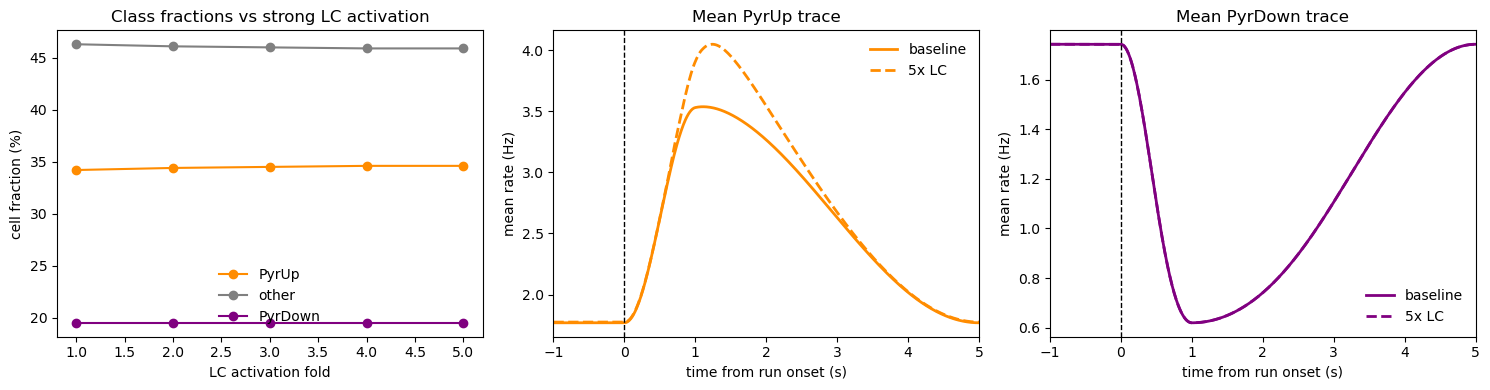

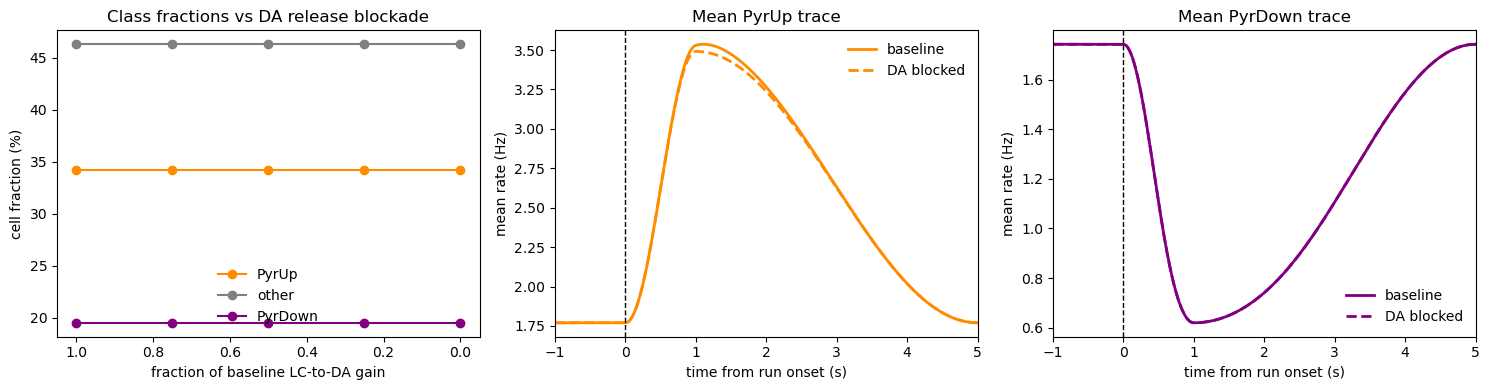

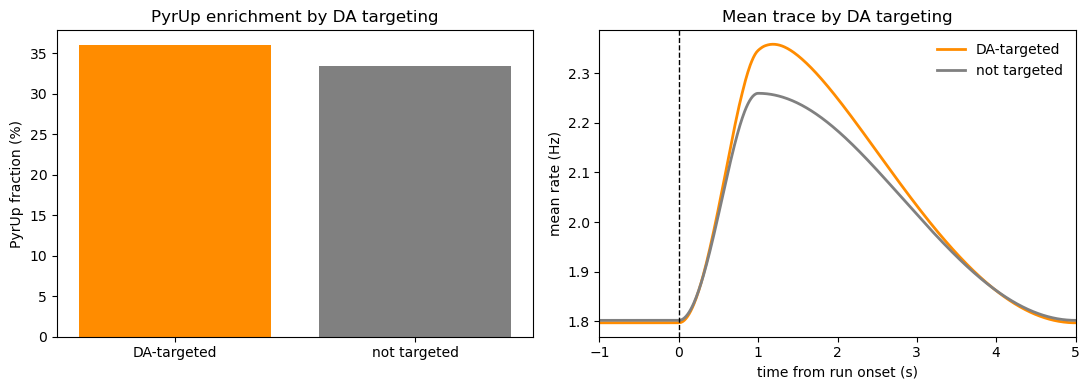

Baseline fractions:
  PyrUp   = 34.2%
  other   = 46.3%
  PyrDown = 19.5%

Strong-LC condition (5x LC):
  PyrUp shift   = +0.40 percentage points
  PyrDown shift = +0.00 percentage points

DA-block condition (LC-to-DA gain = 0.0):
  PyrUp shift   = +0.00 percentage points
  PyrDown shift = +0.00 percentage points

DA-targeting effect:
  PyrUp fraction if DA-targeted     = 36.0%
  PyrUp fraction if not DA-targeted = 33.4%
  mean post-run rate if DA-targeted     = 2.28 Hz
  mean post-run rate if not DA-targeted = 2.21 Hz


In [ ]:
# test 1: do strong LC activation and DA block reproduce the core manuscript phenomena?
base_result = simulate_fixed_population(PARAMS(), pop)

# 1. increase LC activity by a fold-change relative to baseline
lc_fold_values = [1.0, 2.0, 3.0, 4.0, 5.0]
lc_sweep = []
for lc_fold in lc_fold_values:
    p_lc = PARAMS()
    p_lc.lc_amp = p_lc.lc_amp * lc_fold
    lc_sweep.append(simulate_fixed_population(p_lc, pop))

high_lc_result = lc_sweep[-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(lc_fold_values, [100 * np.mean(out['classes']['is_up']) for out in lc_sweep], marker='o', color=class_colors['is_up'], label='PyrUp')
axes[0].plot(lc_fold_values, [100 * np.mean(out['classes']['is_other']) for out in lc_sweep], marker='o', color=class_colors['is_other'], label='other')
axes[0].plot(lc_fold_values, [100 * np.mean(out['classes']['is_down']) for out in lc_sweep], marker='o', color=class_colors['is_down'], label='PyrDown')
axes[0].set_xlabel('LC activation fold')
axes[0].set_ylabel('cell fraction (%)')
axes[0].set_title('Class fractions vs strong LC activation')
axes[0].legend(frameon=False)

axes[1].plot(base_result['t'], base_result['mean_traces']['is_up'], color=class_colors['is_up'], linewidth=2, label='baseline')
axes[1].plot(high_lc_result['t'], high_lc_result['mean_traces']['is_up'], color=class_colors['is_up'], linestyle='--', linewidth=2, label='5x LC')
axes[1].axvline(0, linestyle='--', color='k', linewidth=1)
axes[1].set_xlim([-base_result['p'].t_pre, base_result['p'].drive_end])
axes[1].set_xlabel('time from run onset (s)')
axes[1].set_ylabel('mean rate (Hz)')
axes[1].set_title('Mean PyrUp trace')
axes[1].legend(frameon=False)

axes[2].plot(base_result['t'], base_result['mean_traces']['is_down'], color=class_colors['is_down'], linewidth=2, label='baseline')
axes[2].plot(high_lc_result['t'], high_lc_result['mean_traces']['is_down'], color=class_colors['is_down'], linestyle='--', linewidth=2, label='5x LC')
axes[2].axvline(0, linestyle='--', color='k', linewidth=1)
axes[2].set_xlim([-base_result['p'].t_pre, base_result['p'].drive_end])
axes[2].set_xlabel('time from run onset (s)')
axes[2].set_ylabel('mean rate (Hz)')
axes[2].set_title('Mean PyrDown trace')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

# 2. reduce / block the post-run DA increase
release_gain_scale_values = [1.0, 0.75, 0.5, 0.25, 0.0]
release_sweep = []
for release_scale in release_gain_scale_values:
    p_block = PARAMS()
    p_block.lc_to_da_gain = p_block.lc_to_da_gain * release_scale
    release_sweep.append(simulate_fixed_population(p_block, pop))

blocked_result = release_sweep[-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(release_gain_scale_values, [100 * np.mean(out['classes']['is_up']) for out in release_sweep], marker='o', color=class_colors['is_up'], label='PyrUp')
axes[0].plot(release_gain_scale_values, [100 * np.mean(out['classes']['is_other']) for out in release_sweep], marker='o', color=class_colors['is_other'], label='other')
axes[0].plot(release_gain_scale_values, [100 * np.mean(out['classes']['is_down']) for out in release_sweep], marker='o', color=class_colors['is_down'], label='PyrDown')
axes[0].invert_xaxis()
axes[0].set_xlabel('fraction of baseline LC-to-DA gain')
axes[0].set_ylabel('cell fraction (%)')
axes[0].set_title('Class fractions vs DA release blockade')
axes[0].legend(frameon=False)

axes[1].plot(base_result['t'], base_result['mean_traces']['is_up'], color=class_colors['is_up'], linewidth=2, label='baseline')
axes[1].plot(blocked_result['t'], blocked_result['mean_traces']['is_up'], color=class_colors['is_up'], linestyle='--', linewidth=2, label='DA blocked')
axes[1].axvline(0, linestyle='--', color='k', linewidth=1)
axes[1].set_xlim([-base_result['p'].t_pre, base_result['p'].drive_end])
axes[1].set_xlabel('time from run onset (s)')
axes[1].set_ylabel('mean rate (Hz)')
axes[1].set_title('Mean PyrUp trace')
axes[1].legend(frameon=False)

axes[2].plot(base_result['t'], base_result['mean_traces']['is_down'], color=class_colors['is_down'], linewidth=2, label='baseline')
axes[2].plot(blocked_result['t'], blocked_result['mean_traces']['is_down'], color=class_colors['is_down'], linestyle='--', linewidth=2, label='DA blocked')
axes[2].axvline(0, linestyle='--', color='k', linewidth=1)
axes[2].set_xlim([-base_result['p'].t_pre, base_result['p'].drive_end])
axes[2].set_xlabel('time from run onset (s)')
axes[2].set_ylabel('mean rate (Hz)')
axes[2].set_title('Mean PyrDown trace')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

# 3. DA-targeted vs non-targeted cells at baseline
da_targ_mask = base_result['da_targ']
not_da_targ_mask = ~base_result['da_targ']

p_up_da_targ = 100 * np.mean(base_result['classes']['is_up'][da_targ_mask])
p_up_not_da_targ = 100 * np.mean(base_result['classes']['is_up'][not_da_targ_mask])
post_rate_da_targ = np.mean(base_result['rates'][da_targ_mask][:, base_result['post_mask']], axis=1)
post_rate_not_da_targ = np.mean(base_result['rates'][not_da_targ_mask][:, base_result['post_mask']], axis=1)
mean_trace_da_targ = np.mean(base_result['rates'][da_targ_mask], axis=0)
mean_trace_not_da_targ = np.mean(base_result['rates'][not_da_targ_mask], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(['DA-targeted', 'not targeted'], [p_up_da_targ, p_up_not_da_targ], color=[class_colors['is_up'], class_colors['is_other']])
axes[0].set_ylabel('PyrUp fraction (%)')
axes[0].set_title('PyrUp enrichment by DA targeting')

axes[1].plot(base_result['t'], mean_trace_da_targ, color=class_colors['is_up'], linewidth=2, label='DA-targeted')
axes[1].plot(base_result['t'], mean_trace_not_da_targ, color=class_colors['is_other'], linewidth=2, label='not targeted')
axes[1].axvline(0, linestyle='--', color='k', linewidth=1)
axes[1].set_xlim([-base_result['p'].t_pre, base_result['p'].drive_end])
axes[1].set_xlabel('time from run onset (s)')
axes[1].set_ylabel('mean rate (Hz)')
axes[1].set_title('Mean trace by DA targeting')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print('Baseline fractions:')
print(f'  PyrUp   = {100 * np.mean(base_result["classes"]["is_up"]):.1f}%')
print(f'  other   = {100 * np.mean(base_result["classes"]["is_other"]):.1f}%')
print(f'  PyrDown = {100 * np.mean(base_result["classes"]["is_down"]):.1f}%')
print()
print('Strong-LC condition (5x LC):')
print(f'  PyrUp shift   = {100 * np.mean(high_lc_result["classes"]["is_up"]) - 100 * np.mean(base_result["classes"]["is_up"]):+.2f} percentage points')
print(f'  PyrDown shift = {100 * np.mean(high_lc_result["classes"]["is_down"]) - 100 * np.mean(base_result["classes"]["is_down"]):+.2f} percentage points')
print()
print('DA-block condition (LC-to-DA gain = 0.0):')
print(f'  PyrUp shift   = {100 * np.mean(blocked_result["classes"]["is_up"]) - 100 * np.mean(base_result["classes"]["is_up"]):+.2f} percentage points')
print(f'  PyrDown shift = {100 * np.mean(blocked_result["classes"]["is_down"]) - 100 * np.mean(base_result["classes"]["is_down"]):+.2f} percentage points')
print()
print('DA-targeting effect:')
print(f'  PyrUp fraction if DA-targeted     = {p_up_da_targ:.1f}%')
print(f'  PyrUp fraction if not DA-targeted = {p_up_not_da_targ:.1f}%')
print(f'  mean post-run rate if DA-targeted     = {np.mean(post_rate_da_targ):.2f} Hz')
print(f'  mean post-run rate if not DA-targeted = {np.mean(post_rate_not_da_targ):.2f} Hz')



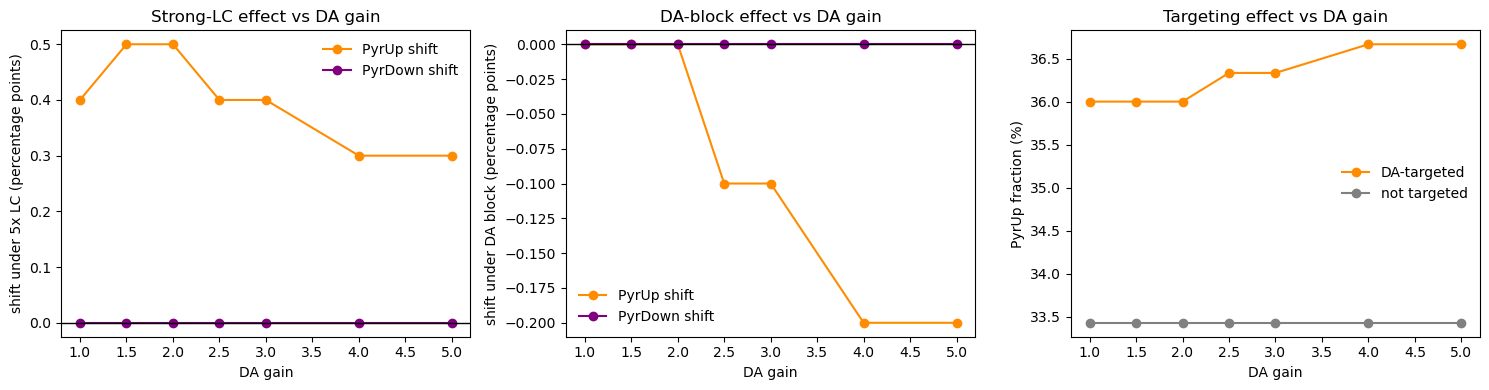

DA gain sweep summary:
da_gain=1.0: 5xLC_up_shift=+0.40 pp, DA_block_up_shift=+0.00 pp, P(PyrUp | da_targ)=36.0%, P(PyrUp | no da_targ)=33.4%
da_gain=1.5: 5xLC_up_shift=+0.50 pp, DA_block_up_shift=+0.00 pp, P(PyrUp | da_targ)=36.0%, P(PyrUp | no da_targ)=33.4%
da_gain=2.0: 5xLC_up_shift=+0.50 pp, DA_block_up_shift=+0.00 pp, P(PyrUp | da_targ)=36.0%, P(PyrUp | no da_targ)=33.4%
da_gain=2.5: 5xLC_up_shift=+0.40 pp, DA_block_up_shift=-0.10 pp, P(PyrUp | da_targ)=36.3%, P(PyrUp | no da_targ)=33.4%
da_gain=3.0: 5xLC_up_shift=+0.40 pp, DA_block_up_shift=-0.10 pp, P(PyrUp | da_targ)=36.3%, P(PyrUp | no da_targ)=33.4%
da_gain=4.0: 5xLC_up_shift=+0.30 pp, DA_block_up_shift=-0.20 pp, P(PyrUp | da_targ)=36.7%, P(PyrUp | no da_targ)=33.4%
da_gain=5.0: 5xLC_up_shift=+0.30 pp, DA_block_up_shift=-0.20 pp, P(PyrUp | da_targ)=36.7%, P(PyrUp | no da_targ)=33.4%


In [ ]:
# test 2: does increasing the global DA gain alone strengthen the strong-LC effect?
sweep_da_gain_values = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
da_gain_summary = []
for sweep_da_gain in sweep_da_gain_values:
    p_base = PARAMS()
    p_base.da_gain = sweep_da_gain

    metrics_row = fixed_population_metrics(p_base, pop, lc_fold=5.0)
    base_out = simulate_fixed_population(p_base, pop)
    da_targ_mask = base_out['da_targ']
    not_da_targ_mask = ~base_out['da_targ']

    da_gain_summary.append({
        'da_gain': sweep_da_gain,
        **metrics_row,
        'p_up_if_da_targ': 100 * np.mean(base_out['classes']['is_up'][da_targ_mask]),
        'p_up_if_not_da_targ': 100 * np.mean(base_out['classes']['is_up'][not_da_targ_mask]),
        'post_rate_da_targ': np.mean(base_out['rates'][da_targ_mask][:, base_out['post_mask']]),
        'post_rate_not_da_targ': np.mean(base_out['rates'][not_da_targ_mask][:, base_out['post_mask']]),
    })

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(sweep_da_gain_values, [row['high_lc_up_shift'] for row in da_gain_summary], marker='o', color=class_colors['is_up'], label='PyrUp shift')
axes[0].plot(sweep_da_gain_values, [row['high_lc_down_shift'] for row in da_gain_summary], marker='o', color=class_colors['is_down'], label='PyrDown shift')
axes[0].axhline(0, color='k', linewidth=1)
axes[0].set_xlabel('DA gain')
axes[0].set_ylabel('shift under 5x LC (percentage points)')
axes[0].set_title('Strong-LC effect vs DA gain')
axes[0].legend(frameon=False)

axes[1].plot(sweep_da_gain_values, [row['block_up_shift'] for row in da_gain_summary], marker='o', color=class_colors['is_up'], label='PyrUp shift')
axes[1].plot(sweep_da_gain_values, [row['block_down_shift'] for row in da_gain_summary], marker='o', color=class_colors['is_down'], label='PyrDown shift')
axes[1].axhline(0, color='k', linewidth=1)
axes[1].set_xlabel('DA gain')
axes[1].set_ylabel('shift under DA block (percentage points)')
axes[1].set_title('DA-block effect vs DA gain')
axes[1].legend(frameon=False)

axes[2].plot(sweep_da_gain_values, [row['p_up_if_da_targ'] for row in da_gain_summary], marker='o', color=class_colors['is_up'], label='DA-targeted')
axes[2].plot(sweep_da_gain_values, [row['p_up_if_not_da_targ'] for row in da_gain_summary], marker='o', color=class_colors['is_other'], label='not targeted')
axes[2].set_xlabel('DA gain')
axes[2].set_ylabel('PyrUp fraction (%)')
axes[2].set_title('Targeting effect vs DA gain')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

print('DA gain sweep summary:')
for row in da_gain_summary:
    print(
        f'da_gain={row["da_gain"]:.1f}: '
        f'5xLC_up_shift={row["high_lc_up_shift"]:+.2f} pp, '
        f'DA_block_up_shift={row["block_up_shift"]:+.2f} pp, '
        f'P(PyrUp | da_targ)={row["p_up_if_da_targ"]:.1f}%, '
        f'P(PyrUp | no da_targ)={row["p_up_if_not_da_targ"]:.1f}%'
    )



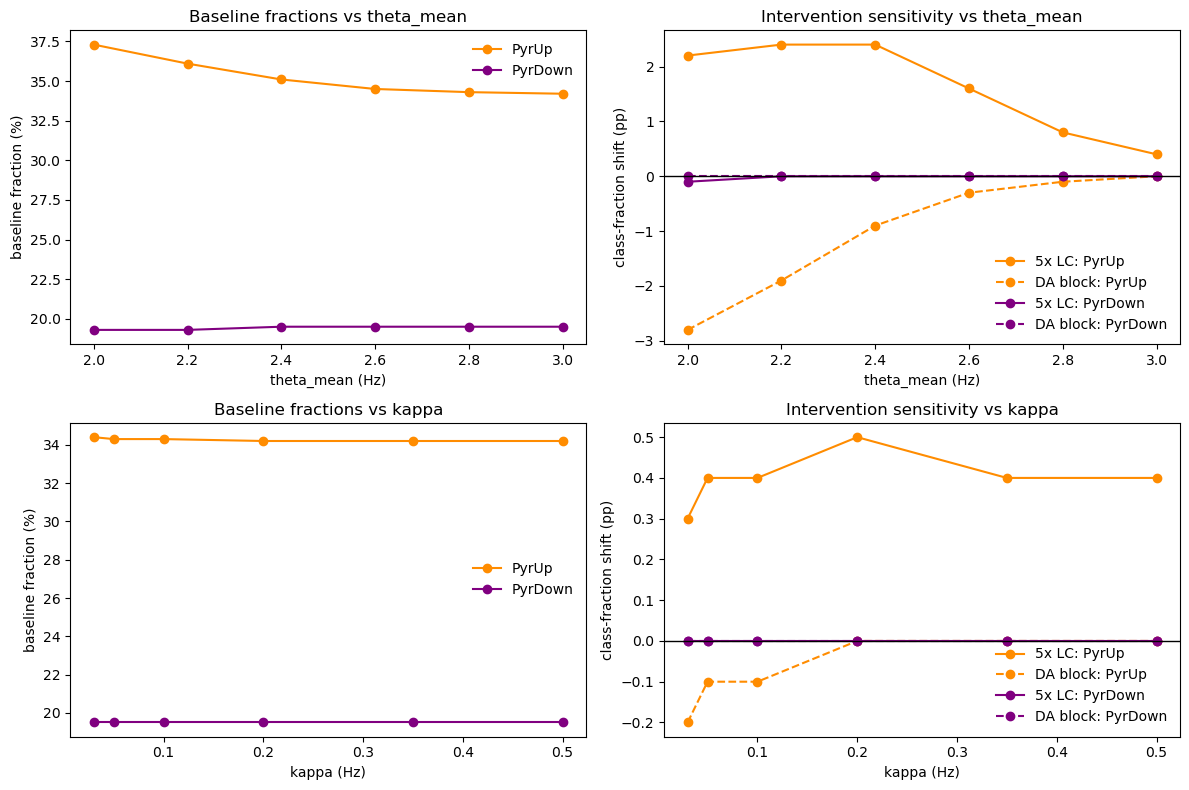

theta_mean sweep summary:
theta_mean=2.00: base_up=37.3%, base_down=19.3%, 5xLC_up_shift=+2.20 pp, DA_block_up_shift=-2.80 pp
theta_mean=2.20: base_up=36.1%, base_down=19.3%, 5xLC_up_shift=+2.40 pp, DA_block_up_shift=-1.90 pp
theta_mean=2.40: base_up=35.1%, base_down=19.5%, 5xLC_up_shift=+2.40 pp, DA_block_up_shift=-0.90 pp
theta_mean=2.60: base_up=34.5%, base_down=19.5%, 5xLC_up_shift=+1.60 pp, DA_block_up_shift=-0.30 pp
theta_mean=2.80: base_up=34.3%, base_down=19.5%, 5xLC_up_shift=+0.80 pp, DA_block_up_shift=-0.10 pp
theta_mean=3.00: base_up=34.2%, base_down=19.5%, 5xLC_up_shift=+0.40 pp, DA_block_up_shift=+0.00 pp

kappa sweep summary:
kappa=0.03: base_up=34.4%, base_down=19.5%, 5xLC_up_shift=+0.30 pp, DA_block_up_shift=-0.20 pp
kappa=0.05: base_up=34.3%, base_down=19.5%, 5xLC_up_shift=+0.40 pp, DA_block_up_shift=-0.10 pp
kappa=0.10: base_up=34.3%, base_down=19.5%, 5xLC_up_shift=+0.40 pp, DA_block_up_shift=-0.10 pp
kappa=0.20: base_up=34.2%, base_down=19.5%, 5xLC_up_shift=+0.50 pp,

In [ ]:
# test 3: does changing the DA recruitment threshold or gate softness help?
theta_mean_values = [2.0, 2.2, 2.4, 2.6, 2.8, 3.0]
kappa_values = [0.03, 0.05, 0.10, 0.20, 0.35, 0.50]

def threshold_metrics(p_variant):
    return fixed_population_metrics(p_variant, pop, lc_fold=5.0)

theta_summary = []
for sweep_theta_mean in theta_mean_values:
    p_theta = PARAMS()
    p_theta.theta_mean = sweep_theta_mean
    theta_summary.append({'theta_mean': sweep_theta_mean, **threshold_metrics(p_theta)})

kappa_summary = []
for sweep_kappa in kappa_values:
    p_kappa = PARAMS()
    p_kappa.kappa = sweep_kappa
    kappa_summary.append({'kappa': sweep_kappa, **threshold_metrics(p_kappa)})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(theta_mean_values, [row['base_up_pct'] for row in theta_summary], marker='o', color=class_colors['is_up'], label='PyrUp')
axes[0, 0].plot(theta_mean_values, [row['base_down_pct'] for row in theta_summary], marker='o', color=class_colors['is_down'], label='PyrDown')
axes[0, 0].set_xlabel('theta_mean (Hz)')
axes[0, 0].set_ylabel('baseline fraction (%)')
axes[0, 0].set_title('Baseline fractions vs theta_mean')
axes[0, 0].legend(frameon=False)

axes[0, 1].plot(theta_mean_values, [row['high_lc_up_shift'] for row in theta_summary], marker='o', color=class_colors['is_up'], label='5x LC: PyrUp')
axes[0, 1].plot(theta_mean_values, [row['block_up_shift'] for row in theta_summary], marker='o', color=class_colors['is_up'], linestyle='--', label='DA block: PyrUp')
axes[0, 1].plot(theta_mean_values, [row['high_lc_down_shift'] for row in theta_summary], marker='o', color=class_colors['is_down'], label='5x LC: PyrDown')
axes[0, 1].plot(theta_mean_values, [row['block_down_shift'] for row in theta_summary], marker='o', color=class_colors['is_down'], linestyle='--', label='DA block: PyrDown')
axes[0, 1].axhline(0, color='k', linewidth=1)
axes[0, 1].set_xlabel('theta_mean (Hz)')
axes[0, 1].set_ylabel('class-fraction shift (pp)')
axes[0, 1].set_title('Intervention sensitivity vs theta_mean')
axes[0, 1].legend(frameon=False)

axes[1, 0].plot(kappa_values, [row['base_up_pct'] for row in kappa_summary], marker='o', color=class_colors['is_up'], label='PyrUp')
axes[1, 0].plot(kappa_values, [row['base_down_pct'] for row in kappa_summary], marker='o', color=class_colors['is_down'], label='PyrDown')
axes[1, 0].set_xlabel('kappa (Hz)')
axes[1, 0].set_ylabel('baseline fraction (%)')
axes[1, 0].set_title('Baseline fractions vs kappa')
axes[1, 0].legend(frameon=False)

axes[1, 1].plot(kappa_values, [row['high_lc_up_shift'] for row in kappa_summary], marker='o', color=class_colors['is_up'], label='5x LC: PyrUp')
axes[1, 1].plot(kappa_values, [row['block_up_shift'] for row in kappa_summary], marker='o', color=class_colors['is_up'], linestyle='--', label='DA block: PyrUp')
axes[1, 1].plot(kappa_values, [row['high_lc_down_shift'] for row in kappa_summary], marker='o', color=class_colors['is_down'], label='5x LC: PyrDown')
axes[1, 1].plot(kappa_values, [row['block_down_shift'] for row in kappa_summary], marker='o', color=class_colors['is_down'], linestyle='--', label='DA block: PyrDown')
axes[1, 1].axhline(0, color='k', linewidth=1)
axes[1, 1].set_xlabel('kappa (Hz)')
axes[1, 1].set_ylabel('class-fraction shift (pp)')
axes[1, 1].set_title('Intervention sensitivity vs kappa')
axes[1, 1].legend(frameon=False)

plt.tight_layout()
plt.show()

print('theta_mean sweep summary:')
for row in theta_summary:
    print(
        f'theta_mean={row["theta_mean"]:.2f}: '
        f'base_up={row["base_up_pct"]:.1f}%, '
        f'base_down={row["base_down_pct"]:.1f}%, '
        f'5xLC_up_shift={row["high_lc_up_shift"]:+.2f} pp, '
        f'DA_block_up_shift={row["block_up_shift"]:+.2f} pp'
    )

print()
print('kappa sweep summary:')
for row in kappa_summary:
    print(
        f'kappa={row["kappa"]:.2f}: '
        f'base_up={row["base_up_pct"]:.1f}%, '
        f'base_down={row["base_down_pct"]:.1f}%, '
        f'5xLC_up_shift={row["high_lc_up_shift"]:+.2f} pp, '
        f'DA_block_up_shift={row["block_up_shift"]:+.2f} pp'
    )



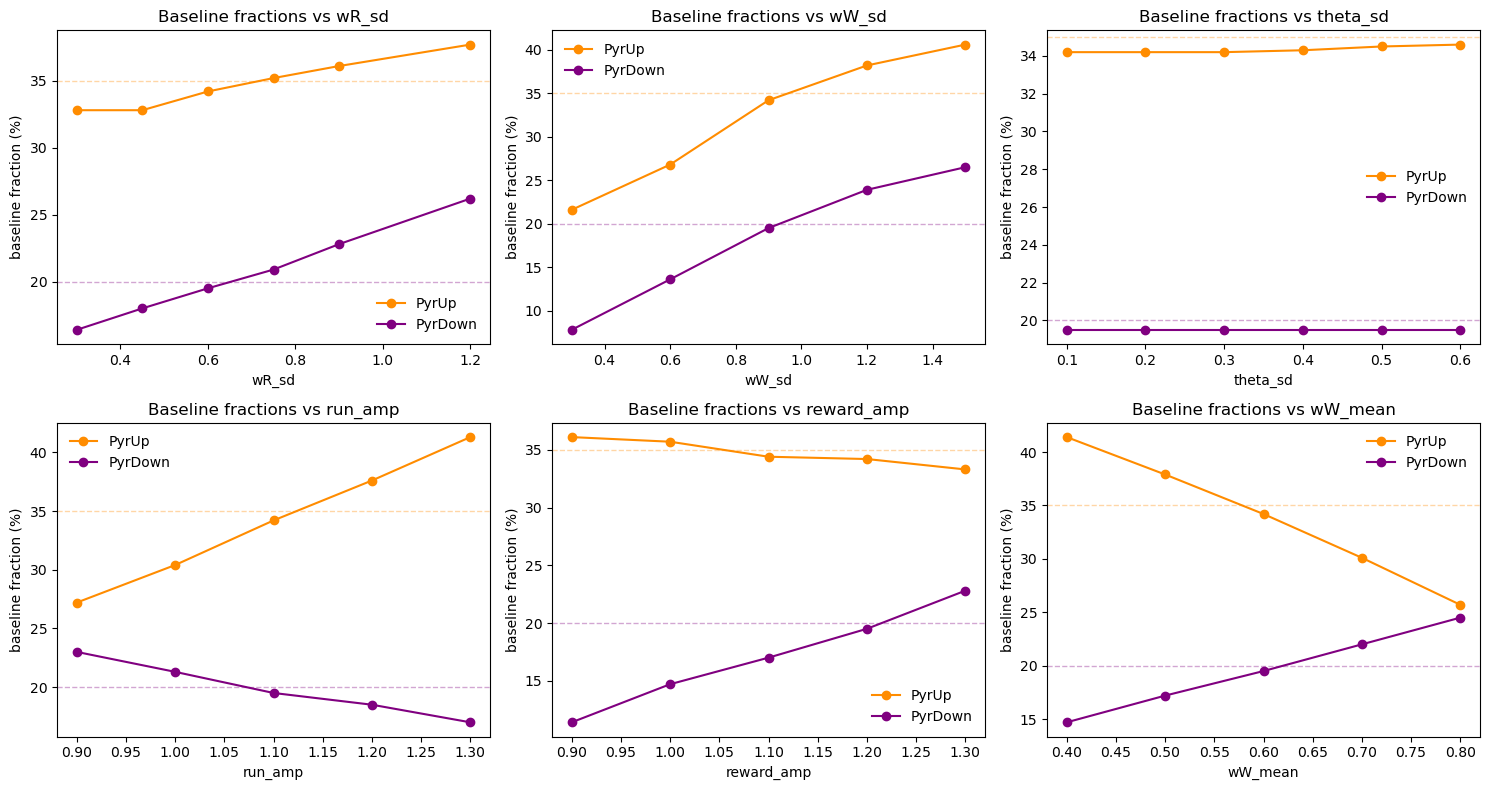

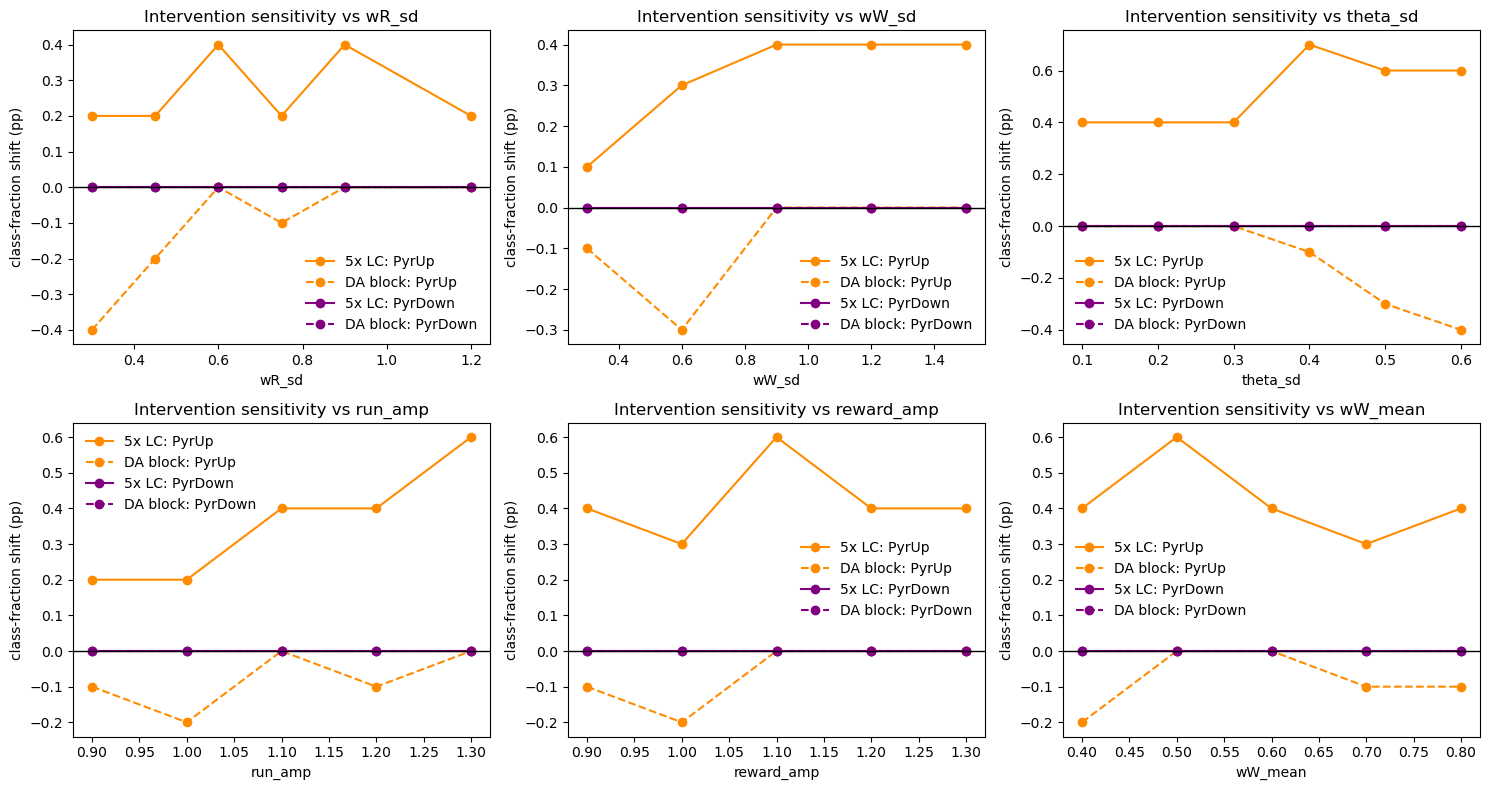

Best single-parameter settings in these sweeps:
  wR_sd = 0.75: base_up=35.2%, base_down=20.9%, 5xLC_up_shift=+0.20 pp, DA_block_up_shift=-0.10 pp, targeting_gap=4.48 pp
  wW_sd = 0.9: base_up=34.2%, base_down=19.5%, 5xLC_up_shift=+0.40 pp, DA_block_up_shift=+0.00 pp, targeting_gap=2.57 pp
  theta_sd = 0.6: base_up=34.6%, base_down=19.5%, 5xLC_up_shift=+0.60 pp, DA_block_up_shift=-0.40 pp, targeting_gap=3.90 pp
  run_amp = 1.2: base_up=37.6%, base_down=18.5%, 5xLC_up_shift=+0.40 pp, DA_block_up_shift=-0.10 pp, targeting_gap=4.38 pp
  reward_amp = 1.0: base_up=35.7%, base_down=14.7%, 5xLC_up_shift=+0.30 pp, DA_block_up_shift=-0.20 pp, targeting_gap=5.19 pp
  wW_mean = 0.6: base_up=34.2%, base_down=19.5%, 5xLC_up_shift=+0.40 pp, DA_block_up_shift=+0.00 pp, targeting_gap=2.57 pp


In [ ]:
# test 4: do direct-drive balance or heterogeneity parameters help?
sweep_specs = {
    'wR_sd': [0.30, 0.45, 0.60, 0.75, 0.90, 1.20],
    'wW_sd': [0.30, 0.60, 0.90, 1.20, 1.50],
    'theta_sd': [0.10, 0.20, 0.30, 0.40, 0.50, 0.60],
    'run_amp': [0.90, 1.00, 1.10, 1.20, 1.30],
    'reward_amp': [0.90, 1.00, 1.10, 1.20, 1.30],
    'wW_mean': [0.40, 0.50, 0.60, 0.70, 0.80]
}

direct_sweep_summary = {}
for param_name, values in sweep_specs.items():
    rows = []
    for value in values:
        p_variant = PARAMS()
        setattr(p_variant, param_name, value)
        rows.append({'value': value, **fixed_population_metrics(p_variant, pop, lc_fold=5.0)})
    direct_sweep_summary[param_name] = rows

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, param_name in zip(axes.flat, sweep_specs.keys()):
    rows = direct_sweep_summary[param_name]
    x = [row['value'] for row in rows]
    ax.plot(x, [row['base_up_pct'] for row in rows], marker='o', color=class_colors['is_up'], label='PyrUp')
    ax.plot(x, [row['base_down_pct'] for row in rows], marker='o', color=class_colors['is_down'], label='PyrDown')
    ax.axhline(35.0, color=class_colors['is_up'], linestyle='--', linewidth=1, alpha=0.35)
    ax.axhline(20.0, color=class_colors['is_down'], linestyle='--', linewidth=1, alpha=0.35)
    ax.set_xlabel(param_name)
    ax.set_ylabel('baseline fraction (%)')
    ax.set_title(f'Baseline fractions vs {param_name}')
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, param_name in zip(axes.flat, sweep_specs.keys()):
    rows = direct_sweep_summary[param_name]
    x = [row['value'] for row in rows]
    ax.plot(x, [row['high_lc_up_shift'] for row in rows], marker='o', color=class_colors['is_up'], label='5x LC: PyrUp')
    ax.plot(x, [row['block_up_shift'] for row in rows], marker='o', color=class_colors['is_up'], linestyle='--', label='DA block: PyrUp')
    ax.plot(x, [row['high_lc_down_shift'] for row in rows], marker='o', color=class_colors['is_down'], label='5x LC: PyrDown')
    ax.plot(x, [row['block_down_shift'] for row in rows], marker='o', color=class_colors['is_down'], linestyle='--', label='DA block: PyrDown')
    ax.axhline(0.0, color='k', linewidth=1)
    ax.set_xlabel(param_name)
    ax.set_ylabel('class-fraction shift (pp)')
    ax.set_title(f'Intervention sensitivity vs {param_name}')
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print('Best single-parameter settings in these sweeps:')
for param_name, rows in direct_sweep_summary.items():
    best_row = max(
        rows,
        key=lambda row: (
            2.0 * row['high_lc_up_shift']
            + 2.0 * (-row['block_up_shift'])
            + 0.4 * row['targeting_gap']
            - 0.2 * abs(row['base_up_pct'] - 35.0)
            - 0.2 * abs(row['base_down_pct'] - 20.0)
            - 0.5 * abs(row['high_lc_down_shift'])
            - 0.5 * abs(row['block_down_shift'])
        )
    )
    print(
        f'  {param_name} = {best_row["value"]}: '
        f'base_up={best_row["base_up_pct"]:.1f}%, '
        f'base_down={best_row["base_down_pct"]:.1f}%, '
        f'5xLC_up_shift={best_row["high_lc_up_shift"]:+.2f} pp, '
        f'DA_block_up_shift={best_row["block_up_shift"]:+.2f} pp, '
        f'targeting_gap={best_row["targeting_gap"]:.2f} pp'
    )



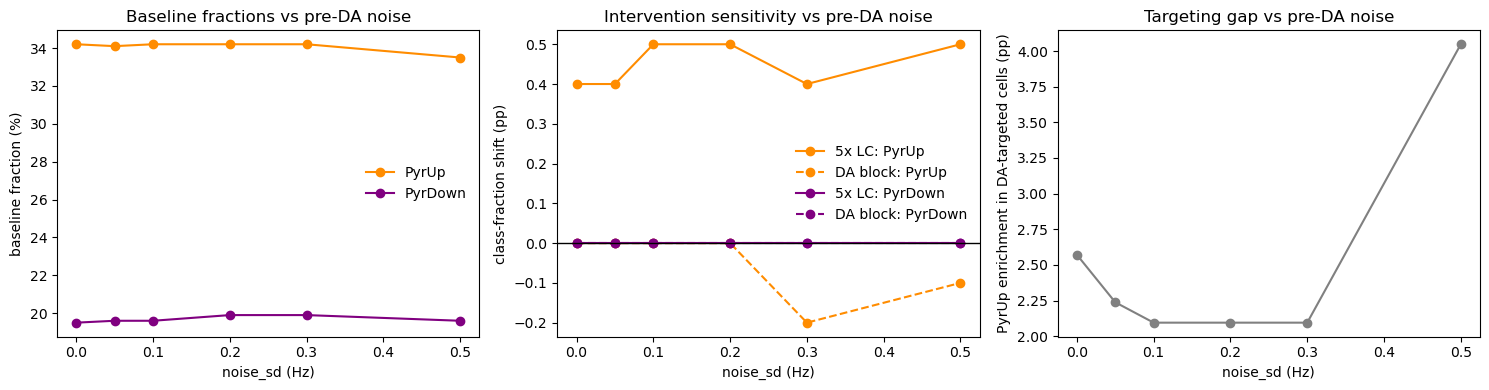

Noise sweep summary:
  noise_sd=0.00: base_up=34.2%, base_down=19.5%, 5xLC_up_shift=+0.40 pp, DA_block_up_shift=+0.00 pp, targeting_gap=2.57 pp
  noise_sd=0.05: base_up=34.1%, base_down=19.6%, 5xLC_up_shift=+0.40 pp, DA_block_up_shift=+0.00 pp, targeting_gap=2.24 pp
  noise_sd=0.10: base_up=34.2%, base_down=19.6%, 5xLC_up_shift=+0.50 pp, DA_block_up_shift=+0.00 pp, targeting_gap=2.10 pp
  noise_sd=0.20: base_up=34.2%, base_down=19.9%, 5xLC_up_shift=+0.50 pp, DA_block_up_shift=+0.00 pp, targeting_gap=2.10 pp
  noise_sd=0.30: base_up=34.2%, base_down=19.9%, 5xLC_up_shift=+0.40 pp, DA_block_up_shift=-0.20 pp, targeting_gap=2.10 pp
  noise_sd=0.50: base_up=33.5%, base_down=19.6%, 5xLC_up_shift=+0.50 pp, DA_block_up_shift=-0.10 pp, targeting_gap=4.05 pp


In [ ]:
# test 5: does adding pre-DA firing-rate noise help?
noise_sd_values = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]
noise_summary = []
for noise_sd in noise_sd_values:
    noise_summary.append({'noise_sd': noise_sd, **fixed_population_metrics(PARAMS(), pop, lc_fold=5.0, noise_sd=noise_sd)})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(noise_sd_values, [row['base_up_pct'] for row in noise_summary], marker='o', color=class_colors['is_up'], label='PyrUp')
axes[0].plot(noise_sd_values, [row['base_down_pct'] for row in noise_summary], marker='o', color=class_colors['is_down'], label='PyrDown')
axes[0].set_xlabel('noise_sd (Hz)')
axes[0].set_ylabel('baseline fraction (%)')
axes[0].set_title('Baseline fractions vs pre-DA noise')
axes[0].legend(frameon=False)

axes[1].plot(noise_sd_values, [row['high_lc_up_shift'] for row in noise_summary], marker='o', color=class_colors['is_up'], label='5x LC: PyrUp')
axes[1].plot(noise_sd_values, [row['block_up_shift'] for row in noise_summary], marker='o', color=class_colors['is_up'], linestyle='--', label='DA block: PyrUp')
axes[1].plot(noise_sd_values, [row['high_lc_down_shift'] for row in noise_summary], marker='o', color=class_colors['is_down'], label='5x LC: PyrDown')
axes[1].plot(noise_sd_values, [row['block_down_shift'] for row in noise_summary], marker='o', color=class_colors['is_down'], linestyle='--', label='DA block: PyrDown')
axes[1].axhline(0.0, color='k', linewidth=1)
axes[1].set_xlabel('noise_sd (Hz)')
axes[1].set_ylabel('class-fraction shift (pp)')
axes[1].set_title('Intervention sensitivity vs pre-DA noise')
axes[1].legend(frameon=False)

axes[2].plot(noise_sd_values, [row['targeting_gap'] for row in noise_summary], marker='o', color=class_colors['is_other'])
axes[2].set_xlabel('noise_sd (Hz)')
axes[2].set_ylabel('PyrUp enrichment in DA-targeted cells (pp)')
axes[2].set_title('Targeting gap vs pre-DA noise')

plt.tight_layout()
plt.show()

print('Noise sweep summary:')
for row in noise_summary:
    print(
        f'  noise_sd={row["noise_sd"]:.2f}: '
        f'base_up={row["base_up_pct"]:.1f}%, '
        f'base_down={row["base_down_pct"]:.1f}%, '
        f'5xLC_up_shift={row["high_lc_up_shift"]:+.2f} pp, '
        f'DA_block_up_shift={row["block_up_shift"]:+.2f} pp, '
        f'targeting_gap={row["targeting_gap"]:.2f} pp'
    )



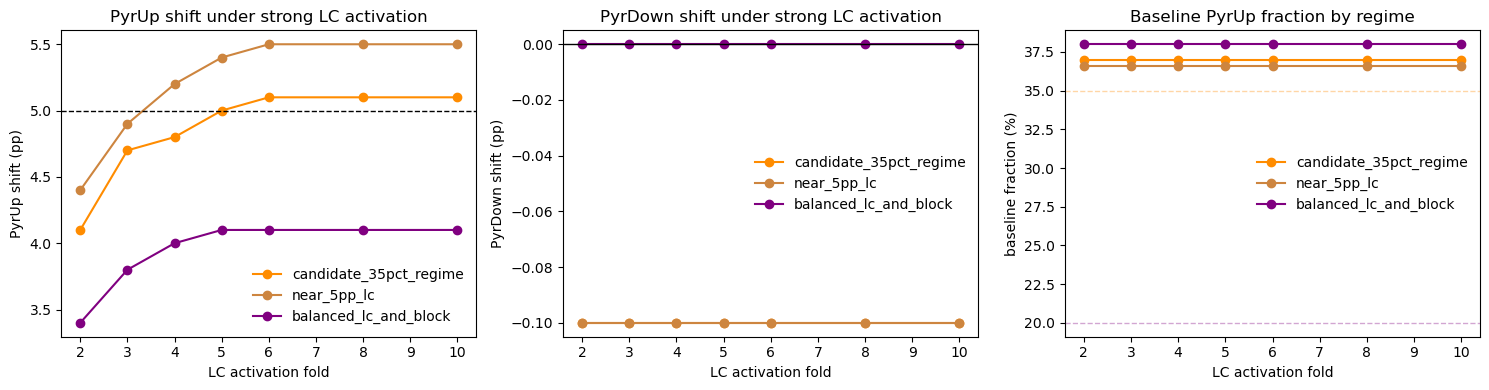

Strong LC activation summary:
  candidate_35pct_regime: base_up=37.0%, base_down=19.0%, fold5_up_shift=+5.00 pp, fold5_down_shift=-0.10 pp, block_up_shift=-0.40 pp, fold6_up_shift=+5.10 pp
  near_5pp_lc: base_up=36.6%, base_down=19.0%, fold5_up_shift=+5.40 pp, fold5_down_shift=-0.10 pp, block_up_shift=+0.00 pp, fold6_up_shift=+5.50 pp
  balanced_lc_and_block: base_up=38.0%, base_down=18.9%, fold5_up_shift=+4.10 pp, fold5_down_shift=+0.00 pp, block_up_shift=-1.40 pp, fold6_up_shift=+4.10 pp


In [ ]:
# test 6: can stronger LC activation (2x to 10x) recover the target PyrUp shift?
strong_lc_regimes = {
    'candidate_35pct_regime': {
        'color': 'darkorange',
        'params': {
            'wR_sd': 0.75,
            'wW_sd': 0.90,
            'run_amp': 1.10,
            'reward_amp': 1.10,
            'theta_mean': 2.20,
            'theta_sd': 0.60,
            'kappa': 0.05,
            'lc_to_da_gain': 4.0,
            'lc_thresh_delta': 1.4,
            'lc_amp': 1.5,
            'da_gain': 1.0,
            'frac_da_targ': 0.35,
        }
    },
    'near_5pp_lc': {
        'color': 'peru',
        'params': {
            'wR_sd': 0.75,
            'wW_sd': 0.90,
            'run_amp': 1.10,
            'reward_amp': 1.10,
            'theta_mean': 2.20,
            'theta_sd': 0.60,
            'kappa': 0.05,
            'lc_to_da_gain': 4.0,
            'lc_thresh_delta': 1.6,
            'lc_amp': 1.5,
            'da_gain': 1.0,
            'frac_da_targ': 0.35,
        }
    },
    'balanced_lc_and_block': {
        'color': 'purple',
        'params': {
            'wR_sd': 0.75,
            'wW_sd': 0.90,
            'run_amp': 1.10,
            'reward_amp': 1.10,
            'theta_mean': 2.20,
            'theta_sd': 0.60,
            'kappa': 0.05,
            'lc_to_da_gain': 4.0,
            'lc_thresh_delta': 1.6,
            'lc_amp': 2.0,
            'da_gain': 1.0,
            'frac_da_targ': 0.35,
        }
    }
}

lc_fold_values = [2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0]
strong_lc_summary = {}
for name, spec in strong_lc_regimes.items():
    p_variant = PARAMS()
    for key, value in spec['params'].items():
        setattr(p_variant, key, value)

    rows = []
    for lc_fold in lc_fold_values:
        rows.append({'lc_fold': lc_fold, **folded_lc_metrics(p_variant, pop, lc_fold=lc_fold)})
    strong_lc_summary[name] = rows

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, spec in strong_lc_regimes.items():
    rows = strong_lc_summary[name]
    x = [row['lc_fold'] for row in rows]
    axes[0].plot(x, [row['high_lc_up_shift'] for row in rows], marker='o', color=spec['color'], label=name)
    axes[1].plot(x, [row['high_lc_down_shift'] for row in rows], marker='o', color=spec['color'], label=name)
    axes[2].plot(x, [row['base_up_pct'] for row in rows], marker='o', color=spec['color'], label=name)

axes[0].axhline(5.0, color='k', linestyle='--', linewidth=1)
axes[0].set_xlabel('LC activation fold')
axes[0].set_ylabel('PyrUp shift (pp)')
axes[0].set_title('PyrUp shift under strong LC activation')
axes[0].legend(frameon=False)

axes[1].axhline(0.0, color='k', linewidth=1)
axes[1].set_xlabel('LC activation fold')
axes[1].set_ylabel('PyrDown shift (pp)')
axes[1].set_title('PyrDown shift under strong LC activation')
axes[1].legend(frameon=False)

axes[2].axhline(35.0, color=class_colors['is_up'], linestyle='--', linewidth=1, alpha=0.35)
axes[2].axhline(20.0, color=class_colors['is_down'], linestyle='--', linewidth=1, alpha=0.35)
axes[2].set_xlabel('LC activation fold')
axes[2].set_ylabel('baseline fraction (%)')
axes[2].set_title('Baseline PyrUp fraction by regime')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

print('Strong LC activation summary:')
for name, rows in strong_lc_summary.items():
    row5 = next(row for row in rows if row['lc_fold'] == 5.0)
    row6 = next(row for row in rows if row['lc_fold'] == 6.0)
    print(
        f'  {name}: '
        f'base_up={row5["base_up_pct"]:.1f}%, '
        f'base_down={row5["base_down_pct"]:.1f}%, '
        f'fold5_up_shift={row5["high_lc_up_shift"]:+.2f} pp, '
        f'fold5_down_shift={row5["high_lc_down_shift"]:+.2f} pp, '
        f'block_up_shift={row5["block_up_shift"]:+.2f} pp, '
        f'fold6_up_shift={row6["high_lc_up_shift"]:+.2f} pp'
    )




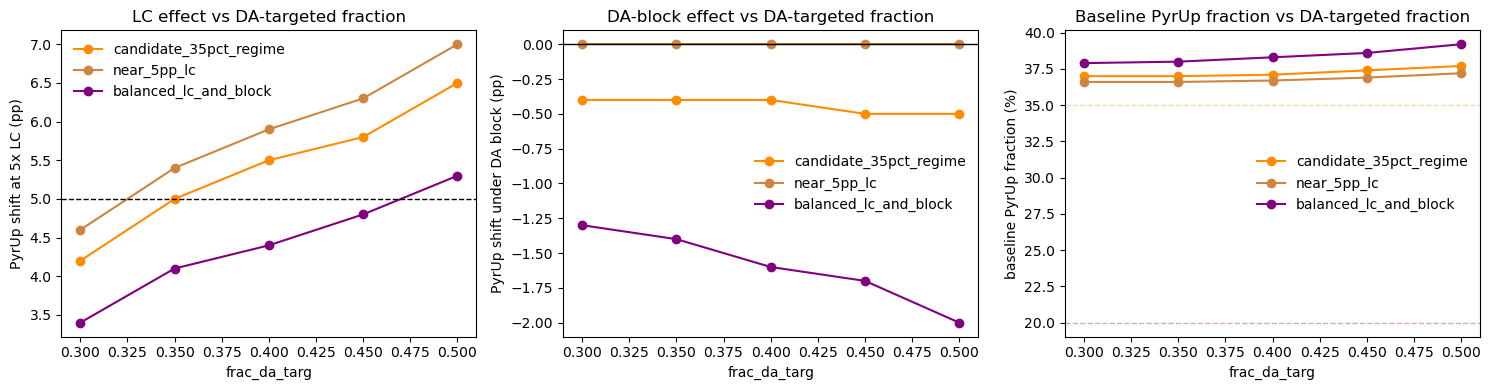

frac_da_targ sweep summary at 5x LC:
  candidate_35pct_regime:
    frac=0.30: base_up=37.0%, base_down=19.1%, LC_up_shift=+4.20 pp, DA_block_up_shift=-0.40 pp
    frac=0.35: base_up=37.0%, base_down=19.0%, LC_up_shift=+5.00 pp, DA_block_up_shift=-0.40 pp
    frac=0.40: base_up=37.1%, base_down=19.0%, LC_up_shift=+5.50 pp, DA_block_up_shift=-0.40 pp
    frac=0.45: base_up=37.4%, base_down=19.0%, LC_up_shift=+5.80 pp, DA_block_up_shift=-0.50 pp
    frac=0.50: base_up=37.7%, base_down=19.0%, LC_up_shift=+6.50 pp, DA_block_up_shift=-0.50 pp
  near_5pp_lc:
    frac=0.30: base_up=36.6%, base_down=19.1%, LC_up_shift=+4.60 pp, DA_block_up_shift=+0.00 pp
    frac=0.35: base_up=36.6%, base_down=19.0%, LC_up_shift=+5.40 pp, DA_block_up_shift=+0.00 pp
    frac=0.40: base_up=36.7%, base_down=19.0%, LC_up_shift=+5.90 pp, DA_block_up_shift=+0.00 pp
    frac=0.45: base_up=36.9%, base_down=19.0%, LC_up_shift=+6.30 pp, DA_block_up_shift=+0.00 pp
    frac=0.50: base_up=37.2%, base_down=19.0%, LC_up_shift

In [ ]:
# test 7: does increasing the DA-targeted fraction help under strong LC activation?
frac_sweep_values = [0.30, 0.35, 0.40, 0.45, 0.50]
frac_sweep_regimes = {
    'candidate_35pct_regime': strong_lc_regimes['candidate_35pct_regime'],
    'near_5pp_lc': strong_lc_regimes['near_5pp_lc'],
    'balanced_lc_and_block': strong_lc_regimes['balanced_lc_and_block']
}

frac_sweep_summary = {}
for name, spec in frac_sweep_regimes.items():
    rows = []
    for frac_da_targ in frac_sweep_values:
        p_variant = PARAMS()
        for key, value in spec['params'].items():
            setattr(p_variant, key, value)
        p_variant.frac_da_targ = frac_da_targ

        rows.append({
            'frac_da_targ': frac_da_targ,
            **folded_lc_metrics(p_variant, pop, lc_fold=5.0)
        })
    frac_sweep_summary[name] = rows

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, spec in frac_sweep_regimes.items():
    rows = frac_sweep_summary[name]
    x = [row['frac_da_targ'] for row in rows]
    axes[0].plot(x, [row['high_lc_up_shift'] for row in rows], marker='o', color=spec['color'], label=name)
    axes[1].plot(x, [row['block_up_shift'] for row in rows], marker='o', color=spec['color'], label=name)
    axes[2].plot(x, [row['base_up_pct'] for row in rows], marker='o', color=spec['color'], label=name)

axes[0].axhline(5.0, color='k', linestyle='--', linewidth=1)
axes[0].set_xlabel('frac_da_targ')
axes[0].set_ylabel('PyrUp shift at 5x LC (pp)')
axes[0].set_title('LC effect vs DA-targeted fraction')
axes[0].legend(frameon=False)

axes[1].axhline(0.0, color='k', linewidth=1)
axes[1].set_xlabel('frac_da_targ')
axes[1].set_ylabel('PyrUp shift under DA block (pp)')
axes[1].set_title('DA-block effect vs DA-targeted fraction')
axes[1].legend(frameon=False)

axes[2].axhline(35.0, color=class_colors['is_up'], linestyle='--', linewidth=1, alpha=0.35)
axes[2].axhline(20.0, color=class_colors['is_down'], linestyle='--', linewidth=1, alpha=0.35)
axes[2].set_xlabel('frac_da_targ')
axes[2].set_ylabel('baseline PyrUp fraction (%)')
axes[2].set_title('Baseline PyrUp fraction vs DA-targeted fraction')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

print('frac_da_targ sweep summary at 5x LC:')
for name, rows in frac_sweep_summary.items():
    print(f'  {name}:')
    for row in rows:
        print(
            f'    frac={row["frac_da_targ"]:.2f}: '
            f'base_up={row["base_up_pct"]:.1f}%, '
            f'base_down={row["base_down_pct"]:.1f}%, '
            f'LC_up_shift={row["high_lc_up_shift"]:+.2f} pp, '
            f'DA_block_up_shift={row["block_up_shift"]:+.2f} pp'
        )




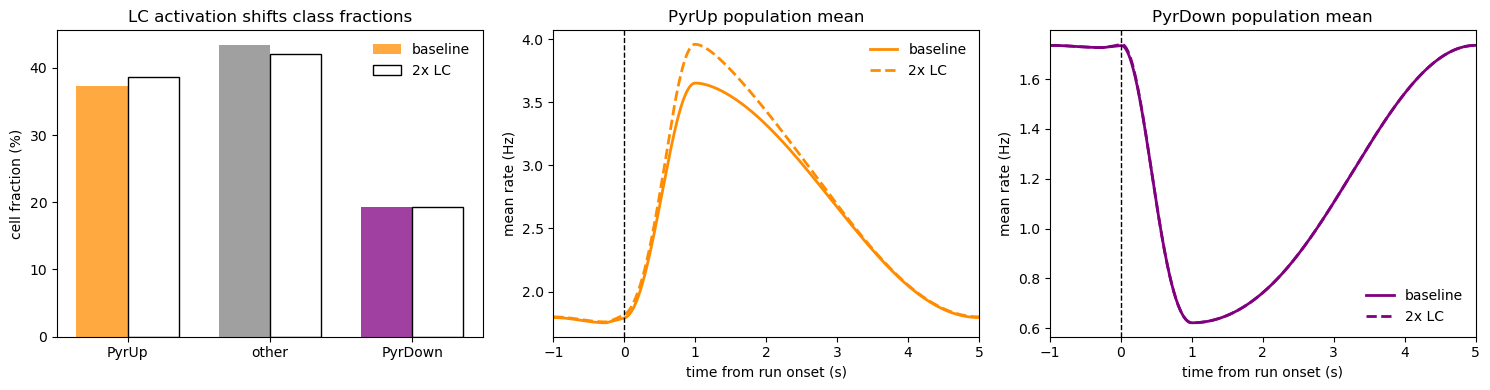

Balanced manuscript candidate regime, LC activation summary:
  baseline PyrUp   = 37.3%
  2x LC PyrUp      = 38.6%
  PyrUp shift      = +1.30 pp
  baseline PyrDown = 19.3%
  2x LC PyrDown    = 19.3%
  PyrDown shift    = +0.00 pp


In [ ]:
# test 8: manuscript-style visualisation of LC activation in a balanced manuscript candidate regime
p_candidate = PARAMS()
p_candidate.wR_sd = 0.75
p_candidate.wW_sd = 0.90
p_candidate.run_amp = 1.10
p_candidate.reward_amp = 1.10
p_candidate.theta_mean = 2.25
p_candidate.theta_sd = 0.20
p_candidate.kappa = 0.25
p_candidate.lc_to_da_gain = 5.5
p_candidate.lc_thresh_delta = 1.30
p_candidate.lc_amp = 1.50
p_candidate.da_gain = 1.75
p_candidate.frac_da_targ = 0.35

candidate_base = simulate_fixed_population(p_candidate, pop)
p_candidate_lc = PARAMS()
p_candidate_lc.__dict__.update(p_candidate.__dict__)
p_candidate_lc.lc_amp = p_candidate.lc_amp * 1.2
candidate_lc = simulate_fixed_population(p_candidate_lc, pop)

base_fracs = [
    100 * np.mean(candidate_base['classes']['is_up']),
    100 * np.mean(candidate_base['classes']['is_other']),
    100 * np.mean(candidate_base['classes']['is_down'])
]
lc_fracs = [
    100 * np.mean(candidate_lc['classes']['is_up']),
    100 * np.mean(candidate_lc['classes']['is_other']),
    100 * np.mean(candidate_lc['classes']['is_down'])
]
labels = ['PyrUp', 'other', 'PyrDown']
bar_colors = [class_colors['is_up'], class_colors['is_other'], class_colors['is_down']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
width = 0.36
x = np.arange(len(labels))
axes[0].bar(x - width / 2, base_fracs, width=width, color=bar_colors, alpha=0.75, label='baseline')
axes[0].bar(x + width / 2, lc_fracs, width=width, color=bar_colors, edgecolor='k', linewidth=1.0, fill=False, label='2x LC')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('cell fraction (%)')
axes[0].set_title('LC activation shifts class fractions')
axes[0].legend(frameon=False)

axes[1].plot(candidate_base['t'], candidate_base['mean_traces']['is_up'], color=class_colors['is_up'], linewidth=2, label='baseline')
axes[1].plot(candidate_lc['t'], candidate_lc['mean_traces']['is_up'], color=class_colors['is_up'], linestyle='--', linewidth=2, label='2x LC')
axes[1].axvline(0, linestyle='--', color='k', linewidth=1)
axes[1].set_xlim([-p_candidate.t_pre, p_candidate.drive_end])
axes[1].set_xlabel('time from run onset (s)')
axes[1].set_ylabel('mean rate (Hz)')
axes[1].set_title('PyrUp population mean')
axes[1].legend(frameon=False)

axes[2].plot(candidate_base['t'], candidate_base['mean_traces']['is_down'], color=class_colors['is_down'], linewidth=2, label='baseline')
axes[2].plot(candidate_lc['t'], candidate_lc['mean_traces']['is_down'], color=class_colors['is_down'], linestyle='--', linewidth=2, label='2x LC')
axes[2].axvline(0, linestyle='--', color='k', linewidth=1)
axes[2].set_xlim([-p_candidate.t_pre, p_candidate.drive_end])
axes[2].set_xlabel('time from run onset (s)')
axes[2].set_ylabel('mean rate (Hz)')
axes[2].set_title('PyrDown population mean')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

print('Balanced manuscript candidate regime, LC activation summary:')
print(f'  baseline PyrUp   = {base_fracs[0]:.1f}%')
print(f'  2x LC PyrUp      = {lc_fracs[0]:.1f}%')
print(f'  PyrUp shift      = {lc_fracs[0] - base_fracs[0]:+.2f} pp')
print(f'  baseline PyrDown = {base_fracs[2]:.1f}%')
print(f'  2x LC PyrDown    = {lc_fracs[2]:.1f}%')
print(f'  PyrDown shift    = {lc_fracs[2] - base_fracs[2]:+.2f} pp')



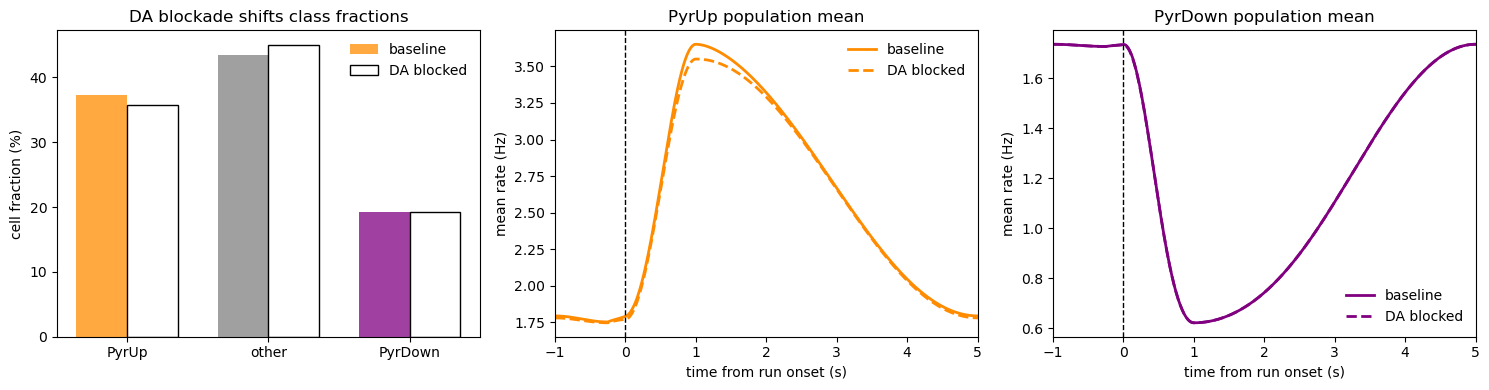

Balanced manuscript candidate regime, DA blockade summary:
  baseline PyrUp    = 37.3%
  DA-block PyrUp    = 35.7%
  PyrUp shift       = -1.60 pp
  baseline PyrDown  = 19.3%
  DA-block PyrDown  = 19.3%
  PyrDown shift     = +0.00 pp


In [ ]:
# test 9: manuscript-style visualisation of DA blockade in a balanced manuscript candidate regime
p_candidate = PARAMS()
p_candidate.wR_sd = 0.75
p_candidate.wW_sd = 0.90
p_candidate.run_amp = 1.10
p_candidate.reward_amp = 1.10
p_candidate.theta_mean = 2.25
p_candidate.theta_sd = 0.20
p_candidate.kappa = 0.25
p_candidate.lc_to_da_gain = 5.5
p_candidate.lc_thresh_delta = 1.30
p_candidate.lc_amp = 1.50
p_candidate.da_gain = 1.75
p_candidate.frac_da_targ = 0.35

candidate_base = simulate_fixed_population(p_candidate, pop)
p_candidate_block = PARAMS()
p_candidate_block.__dict__.update(p_candidate.__dict__)
p_candidate_block.lc_to_da_gain = 0.0
candidate_block = simulate_fixed_population(p_candidate_block, pop)

base_fracs = [
    100 * np.mean(candidate_base['classes']['is_up']),
    100 * np.mean(candidate_base['classes']['is_other']),
    100 * np.mean(candidate_base['classes']['is_down'])
]
block_fracs = [
    100 * np.mean(candidate_block['classes']['is_up']),
    100 * np.mean(candidate_block['classes']['is_other']),
    100 * np.mean(candidate_block['classes']['is_down'])
]
labels = ['PyrUp', 'other', 'PyrDown']
bar_colors = [class_colors['is_up'], class_colors['is_other'], class_colors['is_down']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
width = 0.36
x = np.arange(len(labels))
axes[0].bar(x - width / 2, base_fracs, width=width, color=bar_colors, alpha=0.75, label='baseline')
axes[0].bar(x + width / 2, block_fracs, width=width, color=bar_colors, edgecolor='k', linewidth=1.0, fill=False, label='DA blocked')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('cell fraction (%)')
axes[0].set_title('DA blockade shifts class fractions')
axes[0].legend(frameon=False)

axes[1].plot(candidate_base['t'], candidate_base['mean_traces']['is_up'], color=class_colors['is_up'], linewidth=2, label='baseline')
axes[1].plot(candidate_block['t'], candidate_block['mean_traces']['is_up'], color=class_colors['is_up'], linestyle='--', linewidth=2, label='DA blocked')
axes[1].axvline(0, linestyle='--', color='k', linewidth=1)
axes[1].set_xlim([-p_candidate.t_pre, p_candidate.drive_end])
axes[1].set_xlabel('time from run onset (s)')
axes[1].set_ylabel('mean rate (Hz)')
axes[1].set_title('PyrUp population mean')
axes[1].legend(frameon=False)

axes[2].plot(candidate_base['t'], candidate_base['mean_traces']['is_down'], color=class_colors['is_down'], linewidth=2, label='baseline')
axes[2].plot(candidate_block['t'], candidate_block['mean_traces']['is_down'], color=class_colors['is_down'], linestyle='--', linewidth=2, label='DA blocked')
axes[2].axvline(0, linestyle='--', color='k', linewidth=1)
axes[2].set_xlim([-p_candidate.t_pre, p_candidate.drive_end])
axes[2].set_xlabel('time from run onset (s)')
axes[2].set_ylabel('mean rate (Hz)')
axes[2].set_title('PyrDown population mean')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

print('Balanced manuscript candidate regime, DA blockade summary:')
print(f'  baseline PyrUp    = {base_fracs[0]:.1f}%')
print(f'  DA-block PyrUp    = {block_fracs[0]:.1f}%')
print(f'  PyrUp shift       = {block_fracs[0] - base_fracs[0]:+.2f} pp')
print(f'  baseline PyrDown  = {base_fracs[2]:.1f}%')
print(f'  DA-block PyrDown  = {block_fracs[2]:.1f}%')
print(f'  PyrDown shift     = {block_fracs[2] - base_fracs[2]:+.2f} pp')



## Biological Interpretation and Caveats

This notebook should be read as a **phenomenological systems-neuroscience model**, not as a detailed biophysical circuit model.  
Its main claim is that CA1 activity around run onset can be approximated by the interaction of:

- a run-related excitatory drive, $R(t)$
- a reward-associated suppressive drive, $W(t)$
- a dopamine-dependent gain signal, $D(t)$

In the current formulation, **LC does not drive CA1 directly**. Instead, LC shapes the post-run dopamine transient, and dopamine amplifies only a subset of CA1 cells, mainly when their recent activity is already high enough to recruit the DA gate. In that sense, the model is making a circuit-level statement about **state-dependent amplification**, rather than a claim that DA creates CA1 responses from nothing.

With the baseline parameter set and the exploratory candidate regimes later in the notebook, the model can reproduce several qualitative features of the manuscript:

- strong LC activation can increase the proportion of PyrUp cells
- the PyrUp population mean trace can increase after run onset with little pre-run effect
- PyrDown cells are much less sensitive than PyrUp cells to the DA-mediated LC manipulation
- DA-targeted cells are more likely to fall into the PyrUp class and tend to have higher post-run activity

### Caveats

- The model is **not biophysical**: there are no membrane equations, receptor kinetics, synaptic dynamics, or explicit recurrent CA1 circuitry.
- $R(t)$ and $W(t)$ are **hand-shaped latent drives**, chosen for interpretability rather than derived from upstream data directly.
- The LC-to-DA step is a **compact nonlinear transform**, not a mechanistic model of the LC-VTA/SNc-hippocampal pathway.
- Cell classes depend on the chosen **pre/post windows** and **response-strength thresholds**.
- Trial-to-trial variability is mostly absent apart from optional exploratory noise.
- A good match to the observed phenomena should therefore be interpreted as support for the **logic of the assumptions**, not as proof that the real circuit uses these exact equations.

### Important Simplification About DA Targeting

At the moment, DA sensitivity is still simplified. A cell is either DA-targeted or not, and all DA-targeted cells share the same global gain parameter, `da_gain`. Biologically, real cells almost certainly differ in dopamine receptor expression and downstream sensitivity.

A natural future extension would therefore be:

- keep a binary `da_targ` term for whether a cell belongs to the DA-sensitive subpopulation
- add a continuous per-cell DA sensitivity weight, for example `da_weight_i`

This would preserve the current model logic while allowing different DA-targeted cells to respond with different strengths.

